In [630]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.cluster import AgglomerativeClustering
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_regression, SelectFromModel, RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.pipeline import make_pipeline
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)
print('selected_font:', selected_font)


selected_font: AppleGothic


In [631]:
station_path = '../../../Data/sort_data/preprocessed_6station/ST-481.csv'
df = pd.read_csv(station_path)

drop_mask = df['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')
dropped_rows = int(drop_mask.sum())
df = df.loc[~drop_mask].copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])

station_id = df['station_id'].iloc[0]
print(f"station_id: {station_id}")
print(f'dropped rows (종료_대여소_ID == X): {dropped_rows:,}')
print(f'rows after drop: {len(df):,}')
print(f"time range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

station_id: ST-481
dropped rows (종료_대여소_ID == X): 178
rows after drop: 71,453
time range: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00


In [632]:
hourly = (
    df.sort_values('timestamp')
      .groupby('timestamp')
      .agg(
          inflow=('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
          outflow=('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
          기준_날짜=('기준_날짜', 'first'),
          시간대=('시간대', 'first'),
          집계_기준=('집계_기준', 'first'),
          station_id=('station_id', 'first'),
          온도=('온도', 'first'),
          습도=('습도', 'first'),
          강수량=('강수량', 'first'),
          temp_lag_1hr=('temp_lag_1hr', 'first'),
          위도=('위도', 'first'),
          경도=('경도', 'first'),
          year=('year', 'first'),
          month=('month', 'first'),
          month_sin=('month_sin', 'first'),
          month_cos=('month_cos', 'first'),
          is_restingday=('is_restingday', 'first'),
          weekday_0=('weekday_0', 'first'),
          weekday_1=('weekday_1', 'first'),
          weekday_2=('weekday_2', 'first'),
          weekday_3=('weekday_3', 'first'),
          weekday_4=('weekday_4', 'first'),
          weekday_5=('weekday_5', 'first'),
          weekday_6=('weekday_6', 'first'),
          hour_sin=('hour_sin', 'first'),
          hour_cos=('hour_cos', 'first'),
          is_noon=('is_noon', 'first'),
          is_rushhour=('is_rushhour', 'first'),
          residential_index=('residential_index', 'first'),
          business_index=('business_index', 'first'),
          tourism_index=('tourism_index', 'first'),
          transit_index=('transit_index', 'first'),
          commute_in_index=('commute_in_index', 'first'),
          commute_out_index=('commute_out_index', 'first'),
          snow_flag=('snow_flag', 'first')
      )
      .reset_index()
)

hourly['total_flow'] = hourly['inflow'] + hourly['outflow']
hourly['net_flow'] = hourly['inflow'] - hourly['outflow']

hourly.head()

,timestamp,inflow,outflow,기준_날짜,시간대,집계_기준,station_id,온도,습도,강수량,...,is_rushhour,residential_index,business_index,tourism_index,transit_index,commute_in_index,commute_out_index,snow_flag,total_flow,net_flow
0,2024-01-01 00:00:00,2,2,2024-01-01,0,출발시간,ST-481,-2.7,92,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,4,0
1,2024-01-01 01:00:00,0,3,2024-01-01,1,출발시간,ST-481,-1.2,87,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,3,-3
2,2024-01-01 02:00:00,3,0,2024-01-01,2,출발시간,ST-481,-1.2,88,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,3,3
3,2024-01-01 03:00:00,1,2,2024-01-01,3,출발시간,ST-481,-1.1,88,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,3,-1
4,2024-01-01 05:00:00,2,2,2024-01-01,5,출발시간,ST-481,-1.0,87,0.0,...,0,0.012933,0.013751,0.015535,0.0,0.0,0.0,0,4,0


In [633]:
display(hourly[['timestamp', 'station_id', '시간대', 'inflow', 'outflow', 'total_flow', 'net_flow']].head())
display(hourly[['inflow', 'outflow', 'total_flow', 'net_flow']].describe().T)

,timestamp,station_id,시간대,inflow,outflow,total_flow,net_flow
0,2024-01-01 00:00:00,ST-481,0,2,2,4,0
1,2024-01-01 01:00:00,ST-481,1,0,3,3,-3
2,2024-01-01 02:00:00,ST-481,2,3,0,3,3
3,2024-01-01 03:00:00,ST-481,3,1,2,3,-1
4,2024-01-01 05:00:00,ST-481,5,2,2,4,0


,count,mean,std,min,25%,50%,75%,max
inflow,7658.0,4.752677,4.349549,0.0,2.0,4.0,7.0,34.0
outflow,7658.0,4.817838,4.034086,0.0,2.0,4.0,7.0,30.0
total_flow,7658.0,9.570514,7.081850,1.0,4.0,8.0,13.0,54.0
net_flow,7658.0,-0.065161,4.498029,-21.0,-2.0,0.0,2.0,28.0


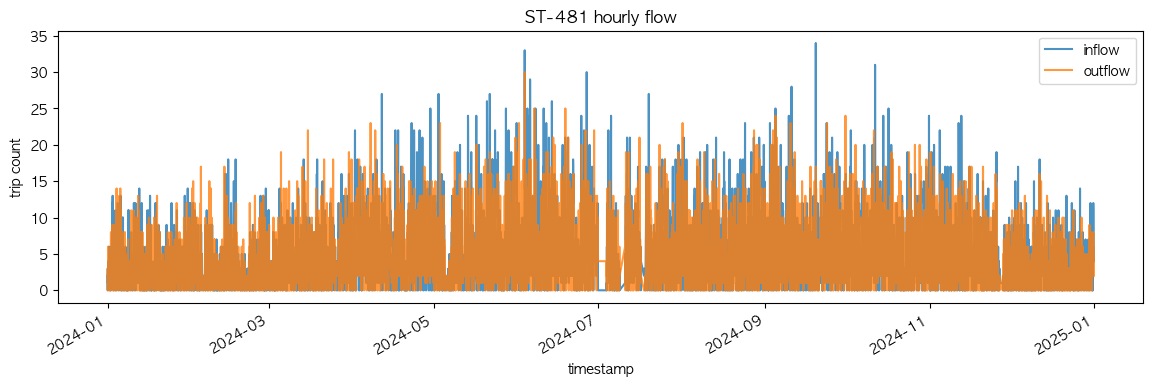

In [634]:
hourly.set_index('timestamp')[['inflow', 'outflow']].plot(alpha=0.8)
plt.title(f'{station_id} hourly flow')
plt.ylabel('trip count')
plt.show()

In [635]:
hourly['week_of_month'] = ((hourly['timestamp'].dt.day - 1) // 7) + 1
hourly['month_label'] = hourly['timestamp'].dt.strftime('%Y-%m')

monthly_weekly_usage = (
    hourly.groupby(['month_label', 'week_of_month'])[['inflow', 'outflow', 'total_flow', 'net_flow']]
          .sum()
          .reset_index()
)

monthly_weekly_usage.head(12)

,month_label,week_of_month,inflow,outflow,total_flow,net_flow
0,2024-01,1,540,526,1066,14
1,2024-01,2,452,465,917,-13
2,2024-01,3,419,443,862,-24
3,2024-01,4,449,397,846,52
4,2024-01,5,271,251,522,20
5,2024-02,1,500,519,1019,-19
6,2024-02,2,458,507,965,-49
7,2024-02,3,351,353,704,-2
8,2024-02,4,446,493,939,-47
9,2024-02,5,79,100,179,-21


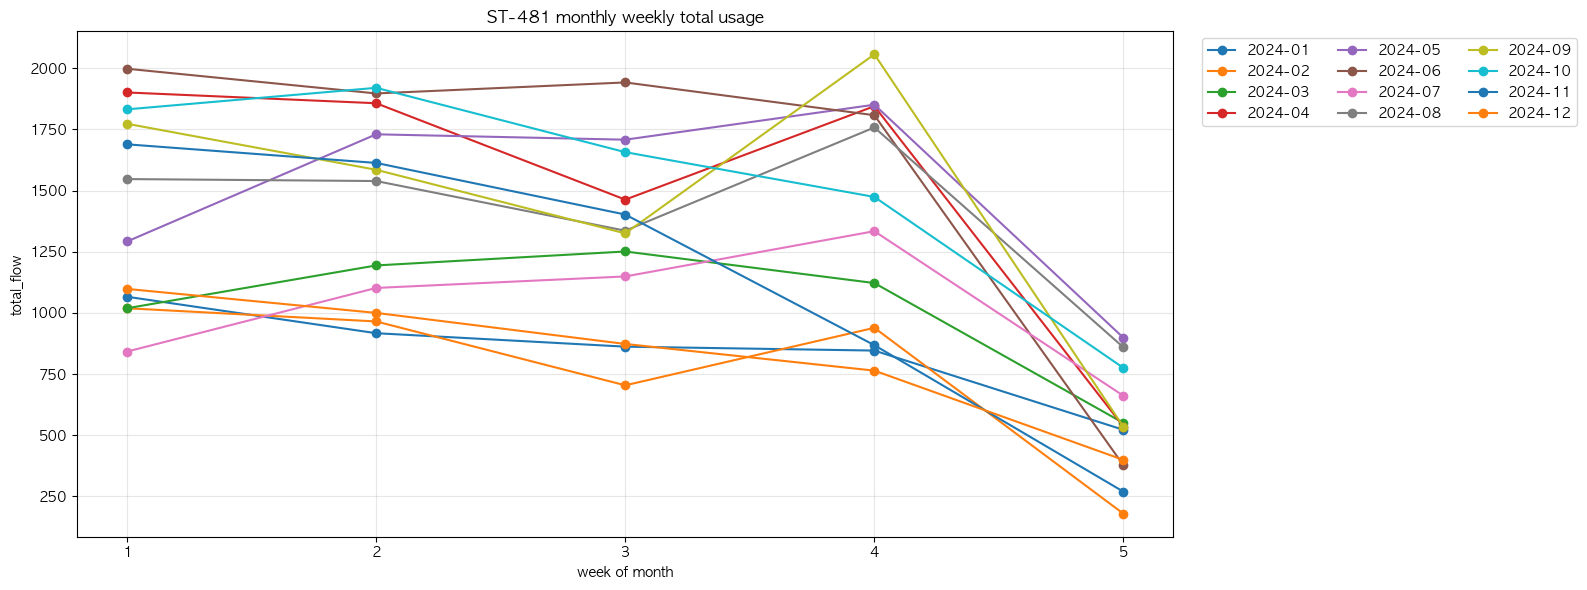

In [636]:
plt.figure(figsize=(16, 6))
for month_label, group in monthly_weekly_usage.groupby('month_label'):
    plt.plot(group['week_of_month'], group['total_flow'], marker='o', label=month_label)

plt.title(f'{station_id} monthly weekly total usage')
plt.xlabel('week of month')
plt.ylabel('total_flow')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

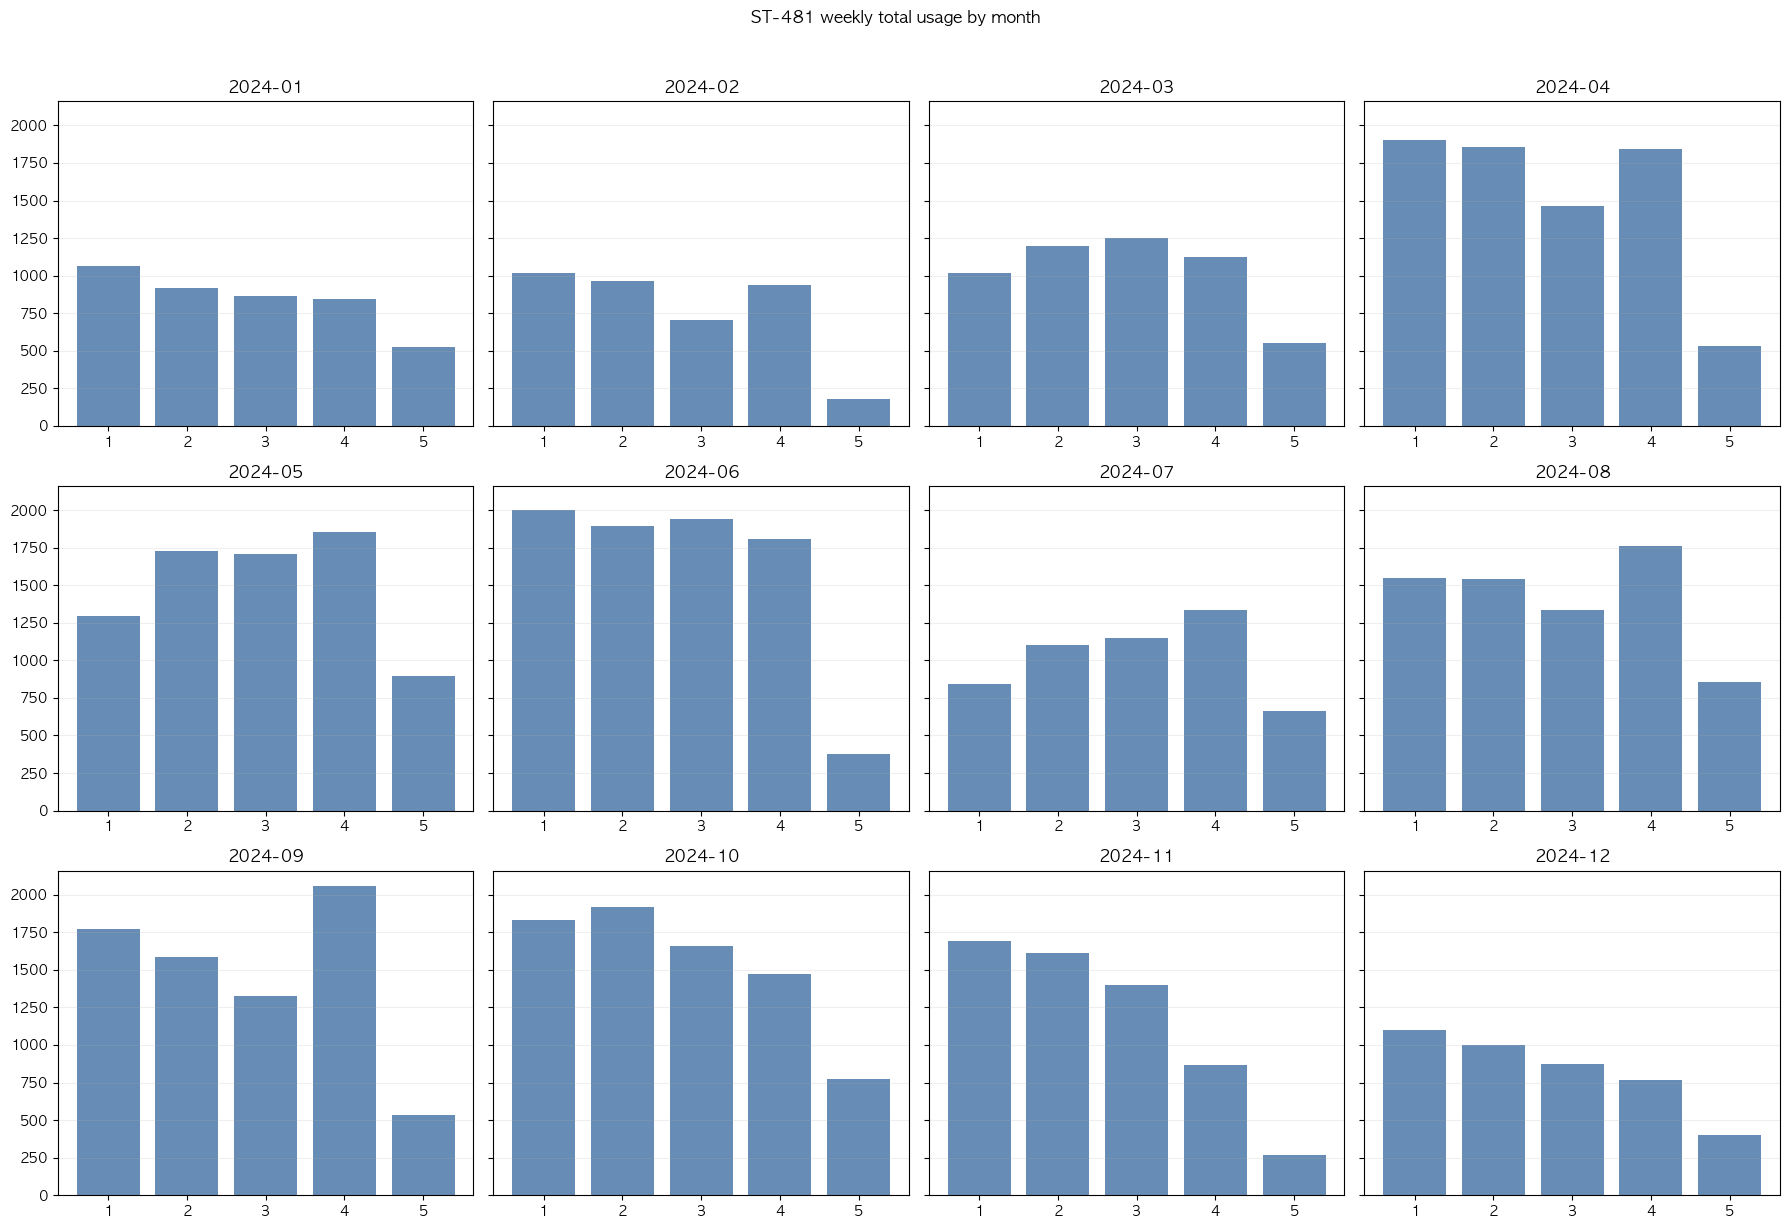

In [637]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for ax, month_label in zip(axes, sorted(monthly_weekly_usage['month_label'].unique())):
    month_data = monthly_weekly_usage[monthly_weekly_usage['month_label'] == month_label]
    ax.bar(month_data['week_of_month'], month_data['total_flow'], color='#4C78A8', alpha=0.85)
    ax.set_title(month_label)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis='y', alpha=0.2)

for ax in axes[len(monthly_weekly_usage['month_label'].unique()):]:
    ax.axis('off')

fig.suptitle(f'{station_id} weekly total usage by month', y=1.02)
fig.tight_layout()
plt.show()

In [638]:
corr_candidates = hourly.select_dtypes(include='number').copy()
constant_cols = corr_candidates.columns[corr_candidates.nunique() <= 1].tolist()
corr_candidates = corr_candidates.drop(columns=constant_cols)
corr_matrix = corr_candidates.corr()
target_cols = ['inflow', 'outflow', 'total_flow', 'net_flow']
display(corr_matrix[target_cols].sort_values('total_flow', ascending=False))
print('dropped constant columns:', constant_cols)

,inflow,outflow,total_flow,net_flow
total_flow,0.857020,0.831464,1.000000,0.083026
inflow,1.000000,0.426302,0.857020,0.584659
outflow,0.426302,1.000000,0.831464,-0.484627
시간대,0.426475,0.250728,0.404757,0.187530
is_noon,0.410636,0.208509,0.370980,0.210078
temp_lag_1hr,0.280089,0.263293,0.322007,0.034707
is_rushhour,0.249915,0.281500,0.313847,-0.010800
온도,0.254090,0.262610,0.305651,0.010179
net_flow,0.584659,-0.484627,0.083026,1.000000
weekday_2,0.048523,0.028142,0.045833,0.021681


dropped constant columns: ['위도', '경도', 'year', 'transit_index', 'commute_in_index', 'commute_out_index']


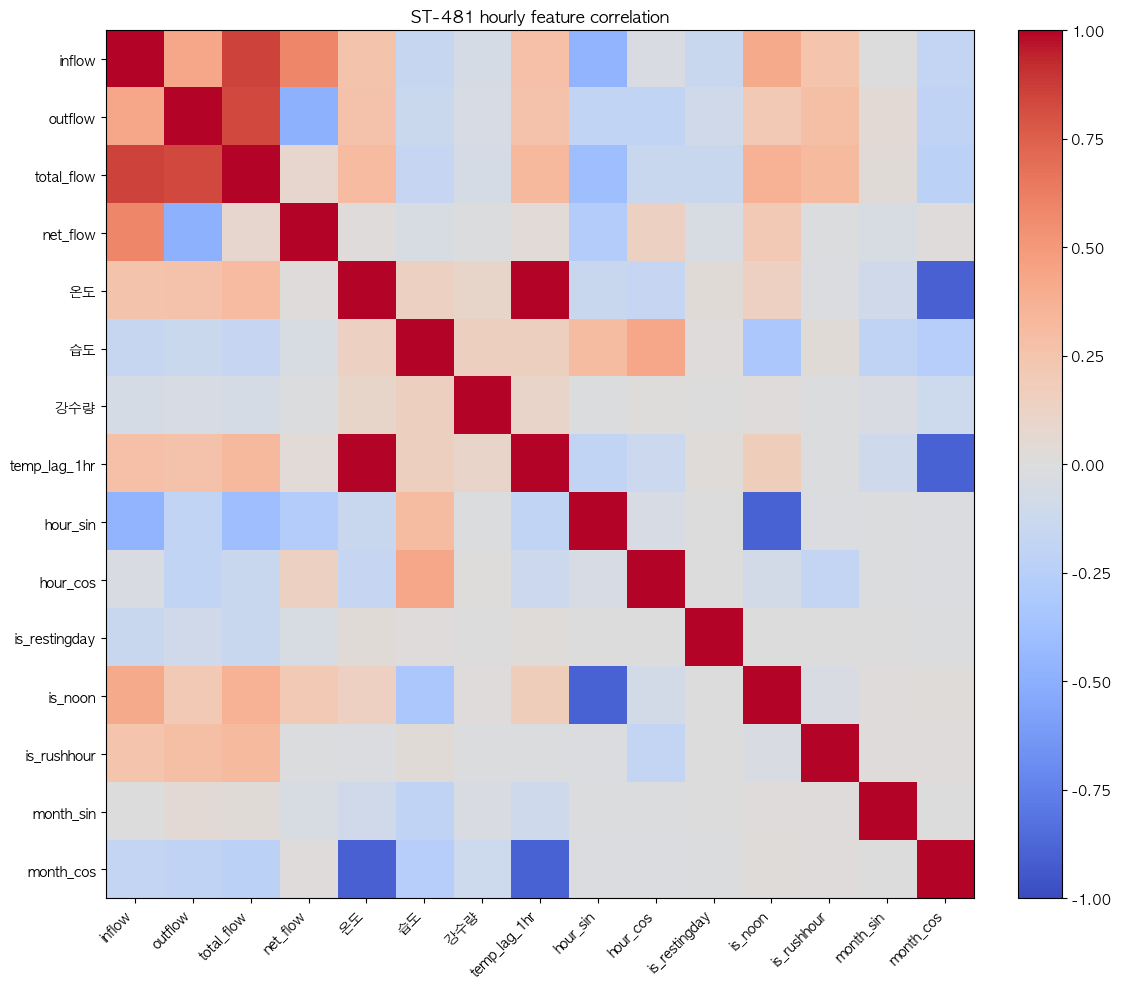

In [639]:
plot_cols = ['inflow', 'outflow', 'total_flow', 'net_flow', '온도', '습도', '강수량', 'temp_lag_1hr', 'hour_sin', 'hour_cos', 'is_restingday', 'is_noon', 'is_rushhour', 'month_sin', 'month_cos']
plot_cols = [col for col in plot_cols if col in corr_matrix.columns]
plot_corr = corr_matrix.loc[plot_cols, plot_cols]

plt.figure(figsize=(12, 10))
im = plt.imshow(plot_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(plot_cols)), plot_cols, rotation=45, ha='right')
plt.yticks(range(len(plot_cols)), plot_cols)
plt.title(f'{station_id} hourly feature correlation')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [640]:
candidate_features = [col for col in corr_matrix.columns if col not in ['inflow', 'outflow', 'total_flow', 'net_flow']]

feature_priority = {
    target: corr_matrix.loc[candidate_features, target].abs().sort_values(ascending=False)
    for target in ['inflow', 'outflow', 'total_flow', 'net_flow']
}

for target, series in feature_priority.items():
    print(f'\n[{target}] top features')
    display(series.head(10).to_frame(name='abs_corr'))

selected_features = sorted(set(
    feature_priority['total_flow'].head(8).index.tolist()
    + feature_priority['inflow'].head(8).index.tolist()
    + feature_priority['outflow'].head(8).index.tolist()
))

print('\nrecommended features for first model:')
print(selected_features)


[inflow] top features


,abs_corr
hour_sin,0.462875
시간대,0.426475
is_noon,0.410636
temp_lag_1hr,0.280089
온도,0.254090
is_rushhour,0.249915
month_cos,0.175709
습도,0.159687
is_restingday,0.135234
business_index,0.121675



[outflow] top features


,abs_corr
is_rushhour,0.281500
temp_lag_1hr,0.263293
온도,0.262610
시간대,0.250728
is_noon,0.208509
month_cos,0.201560
hour_cos,0.193220
hour_sin,0.191832
business_index,0.149282
습도,0.126797



[total_flow] top features


,abs_corr
시간대,0.404757
hour_sin,0.393564
is_noon,0.370980
temp_lag_1hr,0.322007
is_rushhour,0.313847
온도,0.305651
month_cos,0.222733
습도,0.170305
business_index,0.159767
is_restingday,0.138175



[net_flow] top features


,abs_corr
hour_sin,0.275550
is_noon,0.210078
시간대,0.187530
hour_cos,0.135898
is_restingday,0.043991
month_sin,0.042280
습도,0.040697
month,0.037425
weekday_6,0.036144
temp_lag_1hr,0.034707



recommended features for first model:
['hour_cos', 'hour_sin', 'is_noon', 'is_rushhour', 'month_cos', 'temp_lag_1hr', '습도', '시간대', '온도']


In [641]:
drop_for_linear_regression = [
    'timestamp', '기준_날짜', '집계_기준', 'station_id',
    '위도', '경도', 'year',
    'temp_lag_1hr',
    'month',
    '시간대', 'is_noon', 'is_rushhour',
    'weekday_0',
    'residential_index', 'business_index', 'tourism_index',
    'transit_index', 'commute_in_index', 'commute_out_index'
]

keep_for_linear_regression = [
    '온도', '습도', '강수량',
    'month_sin', 'month_cos',
    'hour_sin', 'hour_cos',
    'is_restingday',
    'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
    'snow_flag'
]

linear_regression_features = [col for col in keep_for_linear_regression if col in hourly.columns]

print('drop_for_linear_regression')
print(drop_for_linear_regression)
print('\nkeep_for_linear_regression')
print(linear_regression_features)

X_linear = hourly[linear_regression_features].copy()
display(X_linear.head())

drop_for_linear_regression
['timestamp', '기준_날짜', '집계_기준', 'station_id', '위도', '경도', 'year', 'temp_lag_1hr', 'month', '시간대', 'is_noon', 'is_rushhour', 'weekday_0', 'residential_index', 'business_index', 'tourism_index', 'transit_index', 'commute_in_index', 'commute_out_index']

keep_for_linear_regression
['온도', '습도', '강수량', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_restingday', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'snow_flag']


,온도,습도,강수량,month_sin,month_cos,hour_sin,hour_cos,is_restingday,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,snow_flag
0,-2.7,92,0.0,0.0,1.0,0.000000,1.000000,1,0,0,0,0,0,0,0
1,-1.2,87,0.0,0.0,1.0,0.258819,0.965926,1,0,0,0,0,0,0,0
2,-1.2,88,0.0,0.0,1.0,0.500000,0.866025,1,0,0,0,0,0,0,0
3,-1.1,88,0.0,0.0,1.0,0.707107,0.707107,1,0,0,0,0,0,0,0
4,-1.0,87,0.0,0.0,1.0,0.965926,0.258819,1,0,0,0,0,0,0,0


In [642]:
split_idx = int(len(hourly) * 0.8)

X = hourly[linear_regression_features].copy()
y_inflow = hourly['inflow'].copy()
y_outflow = hourly['outflow'].copy()

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_inflow_train, y_inflow_test = y_inflow.iloc[:split_idx], y_inflow.iloc[split_idx:]
y_outflow_train, y_outflow_test = y_outflow.iloc[:split_idx], y_outflow.iloc[split_idx:]

print('train shape:', X_train.shape)
print('test shape:', X_test.shape)

train shape: (6126, 15)
test shape: (1532, 15)


In [643]:
inflow_model = LinearRegression()
outflow_model = LinearRegression()

inflow_model.fit(X_train, y_inflow_train)
outflow_model.fit(X_train, y_outflow_train)

inflow_pred = inflow_model.predict(X_test)
outflow_pred = outflow_model.predict(X_test)

metrics_df = pd.DataFrame([
    {
        'target': 'inflow',
        'mae': mean_absolute_error(y_inflow_test, inflow_pred),
        'rmse': mean_squared_error(y_inflow_test, inflow_pred) ** 0.5,
        'r2': r2_score(y_inflow_test, inflow_pred),
    },
    {
        'target': 'outflow',
        'mae': mean_absolute_error(y_outflow_test, outflow_pred),
        'rmse': mean_squared_error(y_outflow_test, outflow_pred) ** 0.5,
        'r2': r2_score(y_outflow_test, outflow_pred),
    }
])

display(metrics_df)

,target,mae,rmse,r2
0,inflow,2.500406,3.276204,0.257802
1,outflow,2.487484,3.235119,0.138725


In [644]:
coef_df = pd.DataFrame({
    'feature': linear_regression_features,
    'inflow_coef': inflow_model.coef_,
    'outflow_coef': outflow_model.coef_,
})

display(coef_df.sort_values('inflow_coef', ascending=False))
display(coef_df.sort_values('outflow_coef', ascending=False))

,feature,inflow_coef,outflow_coef
12,weekday_5,0.746879,1.157117
9,weekday_2,0.293800,0.442117
10,weekday_3,0.047008,0.176758
0,온도,0.007371,0.016363
1,습도,-0.015128,-0.010590
11,weekday_4,-0.032862,0.417653
8,weekday_1,-0.053498,0.228766
3,month_sin,-0.123295,0.142032
13,weekday_6,-0.135358,0.563865
6,hour_cos,-0.229014,-0.944313


,feature,inflow_coef,outflow_coef
12,weekday_5,0.746879,1.157117
13,weekday_6,-0.135358,0.563865
9,weekday_2,0.293800,0.442117
11,weekday_4,-0.032862,0.417653
8,weekday_1,-0.053498,0.228766
10,weekday_3,0.047008,0.176758
3,month_sin,-0.123295,0.142032
0,온도,0.007371,0.016363
1,습도,-0.015128,-0.010590
2,강수량,-0.402908,-0.340572


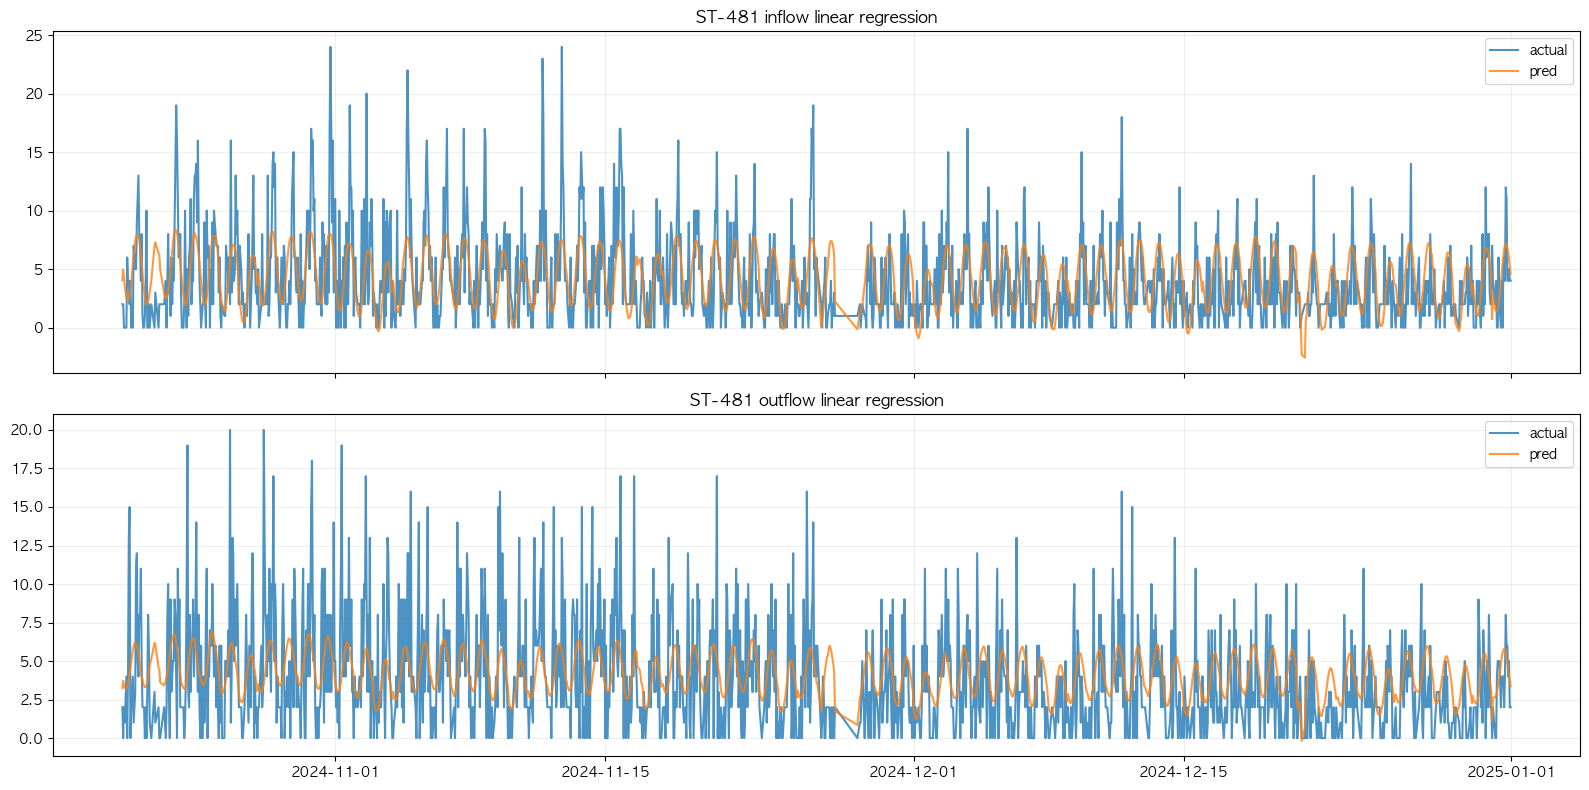

In [645]:
plot_df = pd.DataFrame({
    'timestamp': hourly['timestamp'].iloc[split_idx:],
    'inflow_actual': y_inflow_test.values,
    'inflow_pred': inflow_pred,
    'outflow_actual': y_outflow_test.values,
    'outflow_pred': outflow_pred,
})

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(plot_df['timestamp'], plot_df['inflow_actual'], label='actual', alpha=0.8)
axes[0].plot(plot_df['timestamp'], plot_df['inflow_pred'], label='pred', alpha=0.8)
axes[0].set_title(f'{station_id} inflow linear regression')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(plot_df['timestamp'], plot_df['outflow_actual'], label='actual', alpha=0.8)
axes[1].plot(plot_df['timestamp'], plot_df['outflow_pred'], label='pred', alpha=0.8)
axes[1].set_title(f'{station_id} outflow linear regression')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [646]:
hourly_full = hourly.set_index('timestamp').reindex(pd.date_range(hourly['timestamp'].min(), hourly['timestamp'].max(), freq='h'))
hourly_full.index.name = 'timestamp'

for col in ['inflow', 'outflow', 'total_flow', 'net_flow']:
    hourly_full[col] = hourly_full[col].fillna(0)

fill_cols = ['온도', '습도', '강수량', 'snow_flag', 'is_restingday', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
for col in fill_cols:
    hourly_full[col] = hourly_full[col].ffill().bfill()

hgb_base_features = ['온도', '습도', '강수량', 'snow_flag', 'is_restingday', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
display(hourly_full[hgb_base_features + ['inflow', 'outflow', 'total_flow']].head())

,온도,습도,강수량,snow_flag,is_restingday,month_sin,month_cos,hour_sin,hour_cos,inflow,outflow,total_flow
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,-2.7,92.0,0.0,0.0,1.0,0.0,1.0,0.000000,1.000000,2.0,2.0,4.0
2024-01-01 01:00:00,-1.2,87.0,0.0,0.0,1.0,0.0,1.0,0.258819,0.965926,0.0,3.0,3.0
2024-01-01 02:00:00,-1.2,88.0,0.0,0.0,1.0,0.0,1.0,0.500000,0.866025,3.0,0.0,3.0
2024-01-01 03:00:00,-1.1,88.0,0.0,0.0,1.0,0.0,1.0,0.707107,0.707107,1.0,2.0,3.0
2024-01-01 04:00:00,-1.1,88.0,0.0,0.0,1.0,0.0,1.0,0.707107,0.707107,0.0,0.0,0.0


In [647]:
hgb_validation_artifacts = {}

def run_hgb_validation(target, split_ratio=0.8, valid_ratio=0.2):
    features = hgb_base_features.copy()
    data = hourly_full.dropna(subset=features + [target]).copy()
    split_idx = int(len(data) * split_ratio)
    train = data.iloc[:split_idx].copy()
    test = data.iloc[split_idx:].copy()

    x_input, x_valid, y_input, y_valid = train_test_split(
        train[features],
        train[target],
        test_size=valid_ratio,
        shuffle=False
    )

    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(x_input, np.log1p(y_input))
    pred_input = np.expm1(model.predict(x_input))
    pred_valid = np.expm1(model.predict(x_valid))

    final_model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    final_model.fit(train[features], np.log1p(train[target]))
    pred_test = np.expm1(final_model.predict(test[features]))

    key = target
    hgb_validation_artifacts[key] = {
        'target': target,
        'features': features,
        'model': model,
        'x_input': x_input,
        'y_input': y_input,
        'x_valid': x_valid,
        'y_valid': y_valid,
        'final_model': final_model,
        'train': train,
        'test': test,
    }

    return {
        'target': target,
        'rows': len(data),
        'input_rows': len(x_input),
        'valid_rows': len(x_valid),
        'test_rows': len(test),
        'input_r2': r2_score(y_input, pred_input),
        'valid_r2': r2_score(y_valid, pred_valid),
        'test_r2': r2_score(test[target], pred_test),
        'valid_mae': mean_absolute_error(y_valid, pred_valid),
        'test_mae': mean_absolute_error(test[target], pred_test),
        'valid_rmse': mean_squared_error(y_valid, pred_valid) ** 0.5,
        'test_rmse': mean_squared_error(test[target], pred_test) ** 0.5,
        'artifact_key': key,
    }

validation_results = pd.DataFrame([
    run_hgb_validation('inflow'),
    run_hgb_validation('outflow'),
    run_hgb_validation('total_flow'),
])

display(validation_results[['target', 'rows', 'input_rows', 'valid_rows', 'test_rows', 'input_r2', 'valid_r2', 'test_r2', 'valid_mae', 'test_mae', 'valid_rmse', 'test_rmse', 'artifact_key']])

,target,rows,input_rows,valid_rows,test_rows,input_r2,valid_r2,test_r2,valid_mae,test_mae,valid_rmse,test_rmse,artifact_key
0,inflow,8784,5621,1406,1757,0.714642,0.441479,0.427042,2.581150,2.122158,3.569373,2.882284,inflow
1,outflow,8784,5621,1406,1757,0.652865,0.303534,0.372584,2.740595,2.068946,3.757579,2.788077,outflow
2,total_flow,8784,5621,1406,1757,0.762117,0.503854,0.474010,4.184193,3.262517,5.676883,4.459873,total_flow


In [648]:
monthly_hourly_usage = (
    hourly.groupby(['month', '시간대'])[['inflow', 'outflow', 'total_flow', 'net_flow']]
          .mean()
          .reset_index()
)

monthly_hourly_usage.head(24)

,month,시간대,inflow,outflow,total_flow,net_flow
0,1,0,2.307692,1.346154,3.653846,0.961538
1,1,1,1.636364,1.409091,3.045455,0.227273
2,1,2,1.476190,1.047619,2.523810,0.428571
3,1,3,1.777778,0.666667,2.444444,1.111111
4,1,4,1.176471,0.352941,1.529412,0.823529
5,1,5,0.461538,1.461538,1.923077,-1.000000
6,1,6,1.814815,4.481481,6.296296,-2.666667
7,1,7,1.275862,4.655172,5.931034,-3.379310
8,1,8,4.866667,6.800000,11.666667,-1.933333
9,1,9,1.655172,3.896552,5.551724,-2.241379


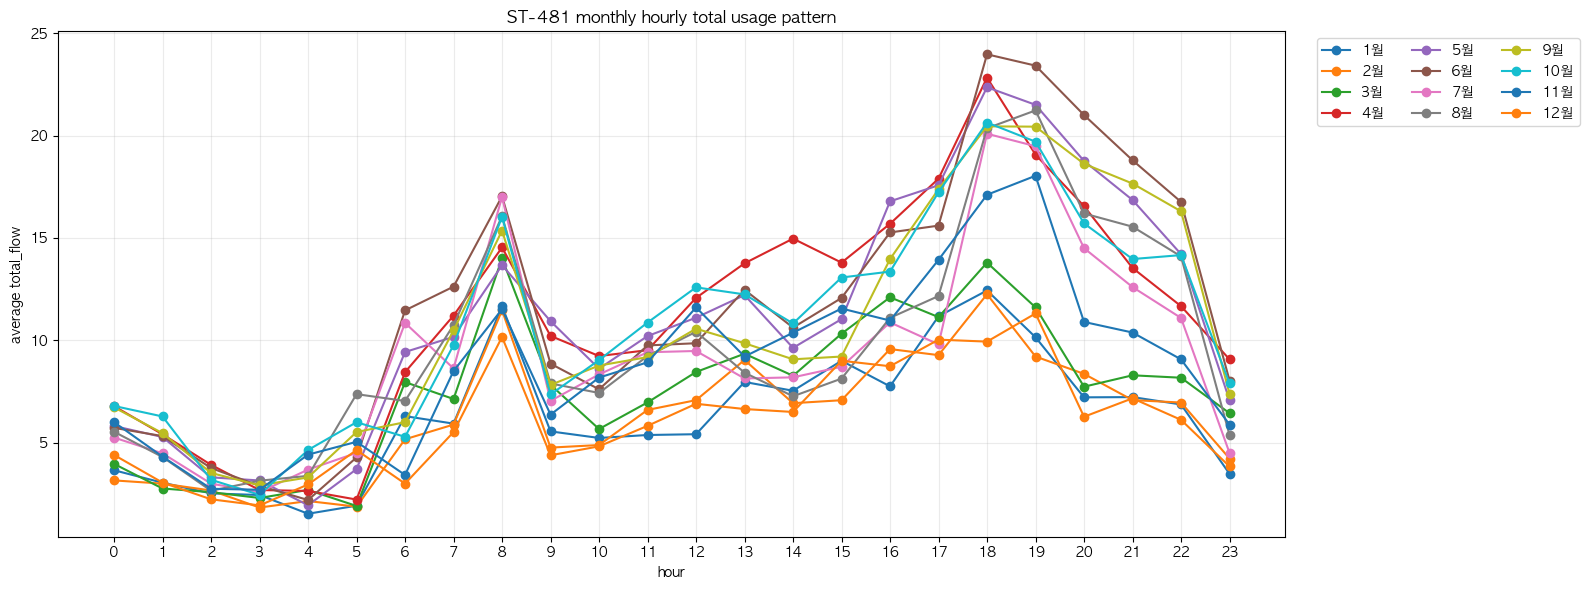

In [649]:
plt.figure(figsize=(16, 6))
for month in sorted(monthly_hourly_usage['month'].unique()):
    month_data = monthly_hourly_usage[monthly_hourly_usage['month'] == month]
    plt.plot(month_data['시간대'], month_data['total_flow'], marker='o', linewidth=1.5, label=f'{month}월')

plt.title(f'{station_id} monthly hourly total usage pattern')
plt.xlabel('hour')
plt.ylabel('average total_flow')
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

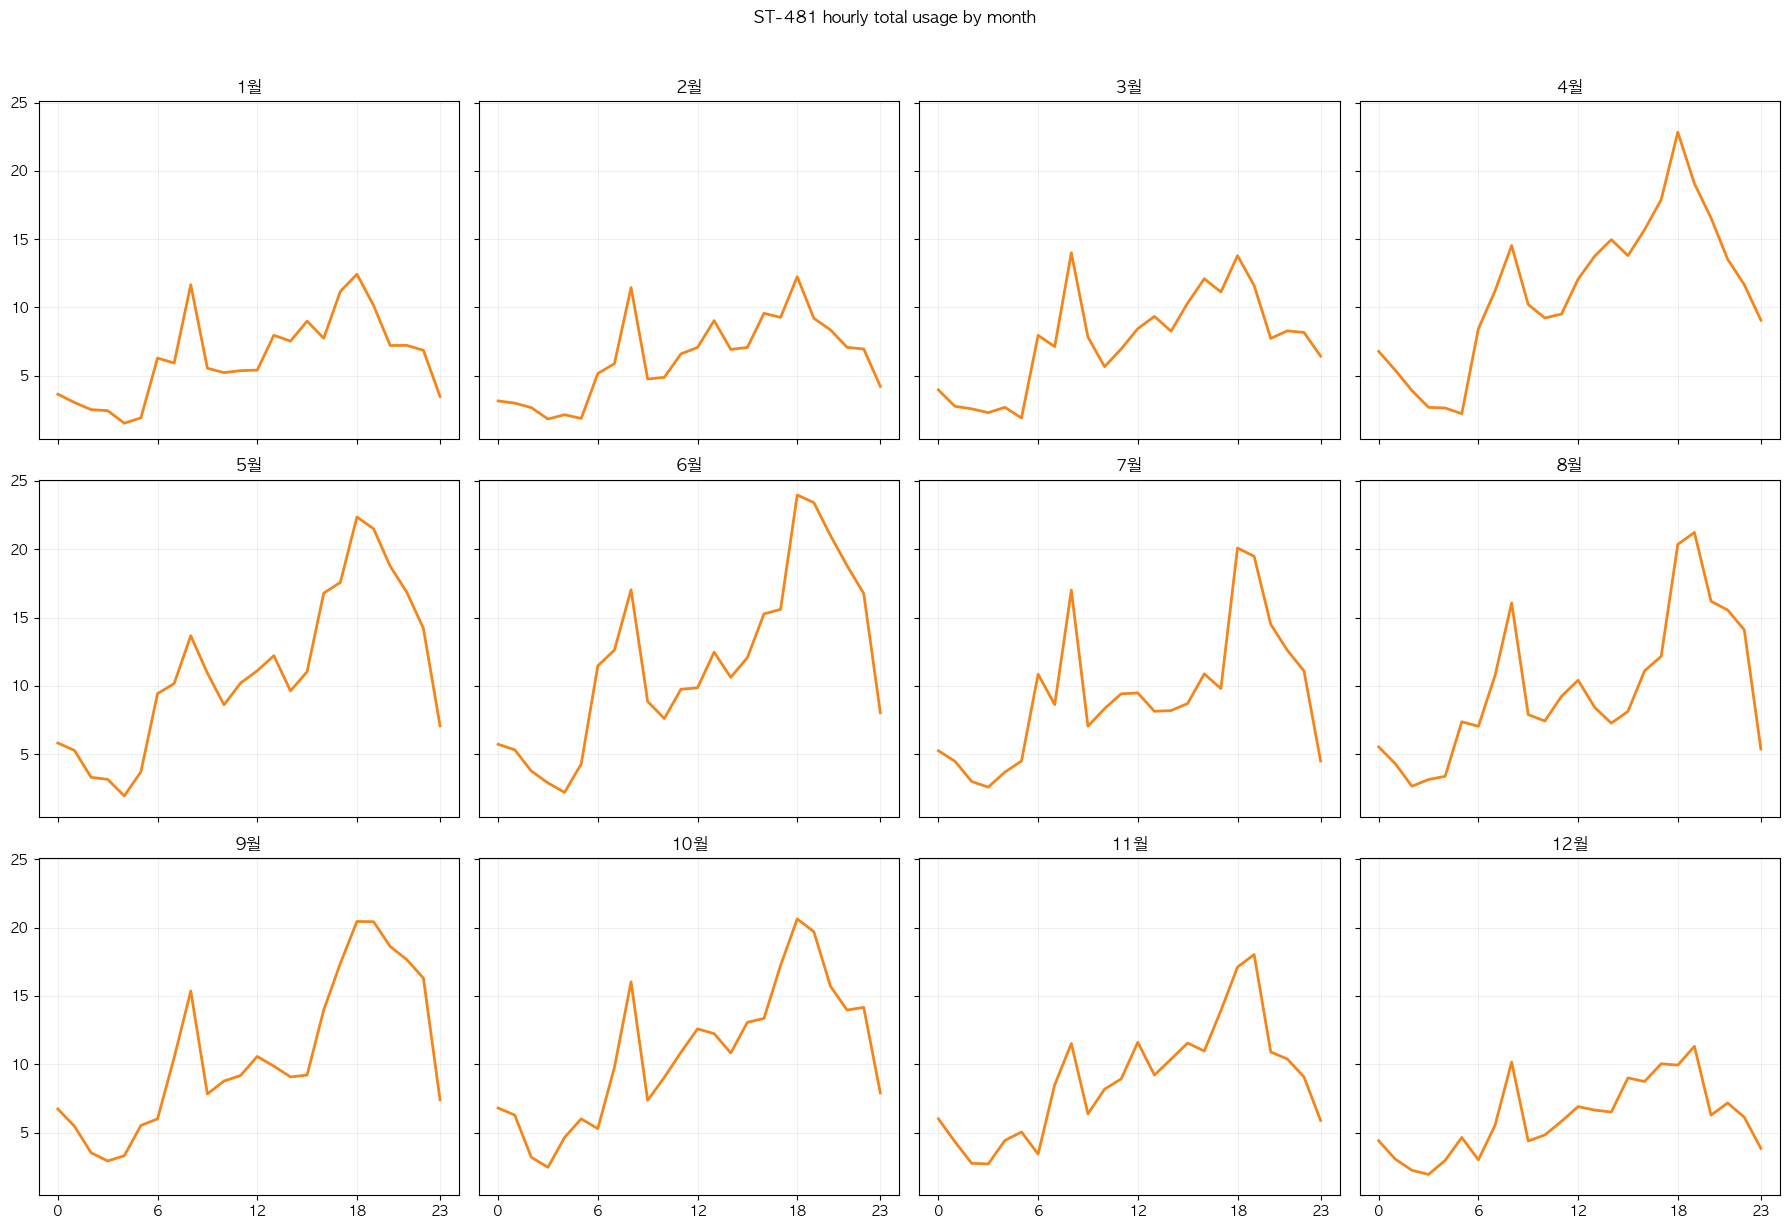

In [650]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, month in zip(axes, sorted(monthly_hourly_usage['month'].unique())):
    month_data = monthly_hourly_usage[monthly_hourly_usage['month'] == month]
    ax.plot(month_data['시간대'], month_data['total_flow'], color='#F58518', linewidth=2)
    ax.set_title(f'{month}월')
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.grid(alpha=0.2)

for ax in axes[len(monthly_hourly_usage['month'].unique()):]:
    ax.axis('off')

fig.suptitle(f'{station_id} hourly total usage by month', y=1.02)
fig.tight_layout()
plt.show()

In [651]:
monthly_hourly_pivot = monthly_hourly_usage.pivot(index='month', columns='시간대', values='total_flow').sort_index()
monthly_hourly_corr = monthly_hourly_pivot.T.corr()
monthly_hourly_cos = pd.DataFrame(
    cosine_similarity(monthly_hourly_pivot),
    index=monthly_hourly_pivot.index,
    columns=monthly_hourly_pivot.index
)

display(monthly_hourly_corr.round(3))
display(monthly_hourly_cos.round(3))

month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.000,0.948,0.952,0.930,0.875,0.867,0.858,0.806,0.832,0.899,0.868,0.905
2,0.948,1.000,0.959,0.939,0.897,0.884,0.873,0.831,0.858,0.923,0.874,0.891
3,0.952,0.959,1.000,0.916,0.861,0.842,0.841,0.777,0.793,0.869,0.841,0.890
4,0.930,0.939,0.916,1.000,0.946,0.916,0.854,0.839,0.893,0.940,0.927,0.879
5,0.875,0.897,0.861,0.946,1.000,0.973,0.906,0.928,0.964,0.940,0.892,0.844
6,0.867,0.884,0.842,0.916,0.973,1.000,0.941,0.956,0.964,0.926,0.856,0.816
7,0.858,0.873,0.841,0.854,0.906,0.941,1.000,0.954,0.895,0.888,0.846,0.812
8,0.806,0.831,0.777,0.839,0.928,0.956,0.954,1.000,0.961,0.923,0.872,0.827
9,0.832,0.858,0.793,0.893,0.964,0.964,0.895,0.961,1.000,0.955,0.887,0.844


month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.000,0.990,0.991,0.987,0.975,0.972,0.972,0.961,0.967,0.982,0.976,0.983
2,0.990,1.000,0.993,0.989,0.979,0.976,0.975,0.966,0.972,0.986,0.978,0.981
3,0.991,0.993,1.000,0.985,0.973,0.967,0.969,0.956,0.960,0.977,0.972,0.981
4,0.987,0.989,0.985,1.000,0.989,0.982,0.971,0.967,0.979,0.989,0.987,0.978
5,0.975,0.979,0.973,0.989,1.000,0.994,0.980,0.985,0.992,0.988,0.978,0.970
6,0.972,0.976,0.967,0.982,0.994,1.000,0.987,0.990,0.992,0.984,0.970,0.963
7,0.972,0.975,0.969,0.971,0.980,0.987,1.000,0.990,0.978,0.978,0.970,0.964
8,0.961,0.966,0.956,0.967,0.985,0.990,0.990,1.000,0.992,0.984,0.974,0.966
9,0.967,0.972,0.960,0.979,0.992,0.992,0.978,0.992,1.000,0.991,0.978,0.970


In [652]:
similarity_pairs = []
months = monthly_hourly_pivot.index.tolist()

for i in range(len(months)):
    for j in range(i + 1, len(months)):
        similarity_pairs.append({
            'month_1': months[i],
            'month_2': months[j],
            'corr': monthly_hourly_corr.loc[months[i], months[j]],
            'cosine': monthly_hourly_cos.loc[months[i], months[j]],
        })

similarity_pairs = pd.DataFrame(similarity_pairs).sort_values(['corr', 'cosine'], ascending=False)
display(similarity_pairs.head(10).round(3))
display(similarity_pairs.tail(10).round(3))

,month_1,month_2,corr,cosine
38,5,6,0.973,0.994
63,10,11,0.966,0.994
47,6,9,0.964,0.992
41,5,9,0.964,0.992
56,8,9,0.961,0.992
11,2,3,0.959,0.993
46,6,8,0.956,0.990
60,9,10,0.955,0.991
51,7,8,0.954,0.990
1,1,3,0.952,0.991


,month_1,month_2,corr,cosine
24,3,7,0.841,0.969
33,4,8,0.839,0.967
7,1,9,0.832,0.967
16,2,8,0.831,0.966
59,8,12,0.827,0.966
50,6,12,0.816,0.963
55,7,12,0.812,0.964
6,1,8,0.806,0.961
26,3,9,0.793,0.960
25,3,8,0.777,0.956


In [653]:
cluster_input = monthly_hourly_pivot.copy()
cluster_scaled = StandardScaler().fit_transform(cluster_input)

cluster_search = []
for k in range(2, 6):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(cluster_scaled)
    cluster_search.append({
        'n_clusters': k,
        'silhouette_score': silhouette_score(cluster_scaled, labels),
    })

cluster_search = pd.DataFrame(cluster_search).sort_values('silhouette_score', ascending=False)
display(cluster_search)

,n_clusters,silhouette_score
0,2,0.447540
1,3,0.330521
2,4,0.299669
3,5,0.264311


In [654]:
best_k = int(cluster_search.iloc[0]['n_clusters'])
month_cluster_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
month_cluster_labels = month_cluster_model.fit_predict(cluster_scaled)

month_cluster_df = pd.DataFrame({
    'month': cluster_input.index,
    'cluster': month_cluster_labels
}).sort_values(['cluster', 'month']).reset_index(drop=True)

display(month_cluster_df)
display(month_cluster_df.groupby('cluster')['month'].apply(list).reset_index(name='months'))

,month,cluster
0,4,0
1,5,0
2,6,0
3,7,0
4,8,0
5,9,0
6,10,0
7,11,0
8,1,1
9,2,1


,cluster,months
0,0,"[4, 5, 6, 7, 8, 9, 10, 11]"
1,1,"[1, 2, 3, 12]"


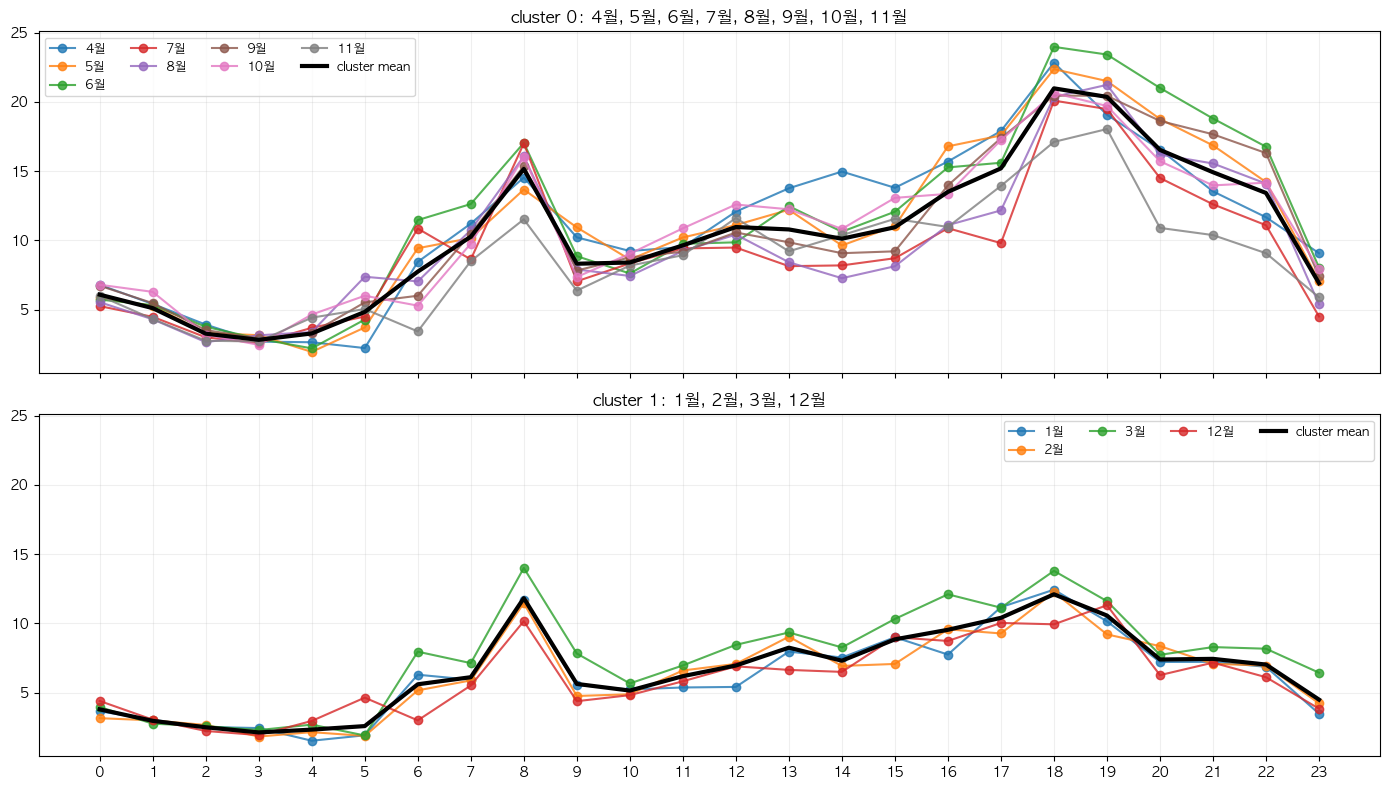

In [655]:
fig, axes = plt.subplots(best_k, 1, figsize=(14, 4 * best_k), sharex=True, sharey=True)
if best_k == 1:
    axes = [axes]

clustered_usage = monthly_hourly_usage.merge(month_cluster_df, on='month', how='left')

for cluster_id, ax in zip(sorted(clustered_usage['cluster'].unique()), axes):
    cluster_data = clustered_usage[clustered_usage['cluster'] == cluster_id]
    for month in sorted(cluster_data['month'].unique()):
        month_data = cluster_data[cluster_data['month'] == month]
        ax.plot(month_data['시간대'], month_data['total_flow'], marker='o', alpha=0.8, label=f'{month}월')

    mean_profile = cluster_data.groupby('시간대')['total_flow'].mean().reset_index()
    ax.plot(mean_profile['시간대'], mean_profile['total_flow'], color='black', linewidth=3, label='cluster mean')
    ax.set_title(f'cluster {cluster_id}: ' + ', '.join([f'{m}월' for m in sorted(cluster_data['month'].unique())]))
    ax.set_xticks(range(24))
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

In [656]:
cluster_profiles = []

for cluster_id in sorted(month_cluster_df['cluster'].unique()):
    months_in_cluster = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
    cluster_matrix = monthly_hourly_pivot.loc[months_in_cluster]
    cluster_center = cluster_matrix.mean(axis=0)

    for month in months_in_cluster:
        distance = np.linalg.norm(cluster_matrix.loc[month] - cluster_center)
        cluster_profiles.append({
            'cluster': cluster_id,
            'month': month,
            'distance_to_center': distance,
        })

cluster_profiles = pd.DataFrame(cluster_profiles).sort_values(['cluster', 'distance_to_center'])
representative_months = cluster_profiles.groupby('cluster', as_index=False).first()
cv_candidate_months = month_cluster_df[~month_cluster_df['month'].isin(representative_months['month'])].copy()

display(cluster_profiles.round(3))
display(representative_months.round(3))
display(cv_candidate_months)

,cluster,month,distance_to_center
6,0,10,5.721
5,0,9,5.969
1,0,5,6.846
4,0,8,7.220
0,0,4,9.103
3,0,7,9.751
2,0,6,10.019
7,0,11,12.063
8,1,1,3.192
9,1,2,3.264


,cluster,month,distance_to_center
0,0,10,5.721
1,1,1,3.192


,month,cluster
0,4,0
1,5,0
2,6,0
3,7,0
4,8,0
5,9,0
7,11,0
9,2,1
10,3,1
11,12,1


In [657]:
hourly_model_data = hourly_full.reset_index().rename(columns={'index': 'timestamp'}).copy()
hourly_model_data['month'] = hourly_model_data['timestamp'].dt.month

selected_train_months = representative_months['month'].tolist()
selected_cv_months = cv_candidate_months['month'].tolist()

cluster_train_data = hourly_model_data[hourly_model_data['month'].isin(selected_train_months)].copy()
cluster_cv_data = hourly_model_data[hourly_model_data['month'].isin(selected_cv_months)].copy()

print('selected_train_months:', selected_train_months)
print('selected_cv_months:', selected_cv_months)
print('train rows:', len(cluster_train_data))
print('cv rows:', len(cluster_cv_data))

selected_train_months: [10, 1]
selected_cv_months: [4, 5, 6, 7, 8, 9, 11, 2, 3, 12]
train rows: 1488
cv rows: 7296


In [658]:
cluster_hgb_results = []

for target in ['inflow', 'outflow', 'total_flow']:
    features = hgb_base_features.copy()
    train_data = cluster_train_data.dropna(subset=features + [target]).copy()
    cv_data = cluster_cv_data.dropna(subset=features + [target]).copy()

    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(train_data[features], np.log1p(train_data[target]))
    pred_train = np.expm1(model.predict(train_data[features]))
    pred_cv = np.expm1(model.predict(cv_data[features]))

    cluster_hgb_results.append({
        'target': target,
        'train_months': selected_train_months,
        'cv_months': selected_cv_months,
        'train_r2': r2_score(train_data[target], pred_train),
        'cv_r2': r2_score(cv_data[target], pred_cv),
        'train_mae': mean_absolute_error(train_data[target], pred_train),
        'cv_mae': mean_absolute_error(cv_data[target], pred_cv),
        'train_rmse': mean_squared_error(train_data[target], pred_train) ** 0.5,
        'cv_rmse': mean_squared_error(cv_data[target], pred_cv) ** 0.5,
    })

cluster_hgb_results = pd.DataFrame(cluster_hgb_results)
display(cluster_hgb_results)

,target,train_months,cv_months,train_r2,cv_r2,train_mae,cv_mae,train_rmse,cv_rmse
0,inflow,"[10, 1]","[4, 5, 6, 7, 8, 9, 11, 2, 3, 12]",0.801450,0.420205,1.264774,2.440883,1.826264,3.359452
1,outflow,"[10, 1]","[4, 5, 6, 7, 8, 9, 11, 2, 3, 12]",0.778081,0.248827,1.219973,2.610009,1.805965,3.593171
2,total_flow,"[10, 1]","[4, 5, 6, 7, 8, 9, 11, 2, 3, 12]",0.836722,0.445294,1.963940,4.058318,2.724766,5.556096


In [659]:
importance_artifact_key = 'total_flow'
importance_artifact = hgb_validation_artifacts[importance_artifact_key]
print('importance_artifact_key:', importance_artifact_key)
print('target:', importance_artifact['target'])
print('n_features:', len(importance_artifact['features']))

importance_artifact_key: total_flow
target: total_flow
n_features: 9


In [660]:
importance_result = permutation_importance(
    importance_artifact['model'],
    importance_artifact['x_valid'],
    np.log1p(importance_artifact['y_valid']),
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

feature_importance_df = pd.DataFrame({
    'feature': importance_artifact['features'],
    'importance_mean': importance_result.importances_mean,
    'importance_std': importance_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

display(feature_importance_df)

,feature,importance_mean,importance_std
0,hour_sin,0.501658,0.029556
1,hour_cos,0.333039,0.014728
2,강수량,0.115322,0.008172
3,is_restingday,0.103910,0.006582
4,습도,0.042963,0.005817
5,온도,0.025326,0.008899
6,snow_flag,0.000000,0.000000
7,month_sin,0.000000,0.000000
8,month_cos,-0.001189,0.000721


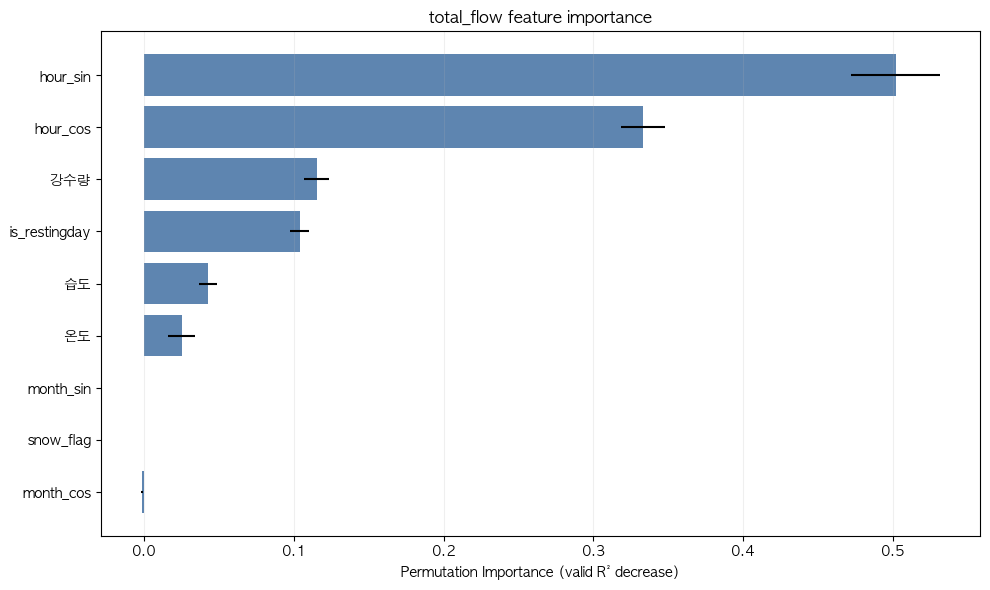

In [661]:
plot_df = feature_importance_df.sort_values('importance_mean', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['feature'], plot_df['importance_mean'], xerr=plot_df['importance_std'], color='#4C78A8', alpha=0.9)
plt.xlabel('Permutation Importance (valid R² decrease)')
plt.title(f"{importance_artifact['target']} feature importance")
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

remaining NaN in X_train: 0
remaining NaN in X_test: 0


,method,n_features,r2,mae,rmse
0,RFECV,10,0.361941,3.540736,4.912064
1,SelectFromModel,8,0.361087,3.548914,4.915350
2,SelectKBest,10,0.335084,3.591338,5.014377


,SelectKBest,SelectFromModel,RFECV
온도,1,1,1
습도,1,1,1
강수량,1,1,1
temp_lag_1hr,1,1,1
위도,0,0,0
경도,0,0,0
year,0,0,0
is_restingday,0,1,1
residential_index,1,1,1
business_index,1,1,1


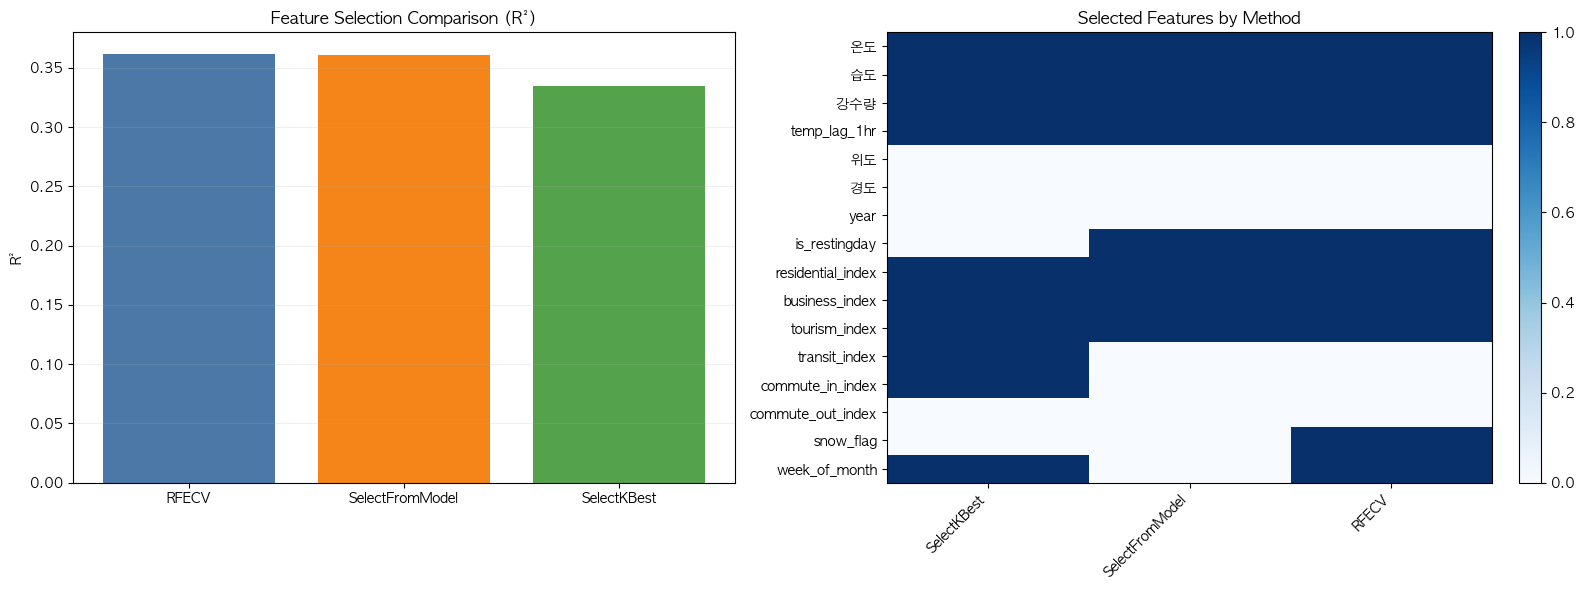


[SelectKBest]
['온도', '습도', '강수량', 'temp_lag_1hr', 'residential_index', 'business_index', 'tourism_index', 'transit_index', 'commute_in_index', 'week_of_month']

[SelectFromModel]
['온도', '습도', '강수량', 'temp_lag_1hr', 'is_restingday', 'residential_index', 'business_index', 'tourism_index']

[RFECV]
['온도', '습도', '강수량', 'temp_lag_1hr', 'is_restingday', 'residential_index', 'business_index', 'tourism_index', 'snow_flag', 'week_of_month']


In [662]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression, SelectFromModel, RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fs_data = hourly_full.reset_index().rename(columns={"index": "timestamp"}).copy()

if "usage" not in fs_data.columns:
    fs_data["usage"] = fs_data["total_flow"]

time_cols = [
    "timestamp", "기준_날짜", "시간대", "month",
    "month_sin", "month_cos",
    "hour_sin", "hour_cos",
    "is_noon", "is_rushhour",
    "weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "weekday_6",
]

target_like_cols = ["inflow", "outflow", "total_flow", "net_flow", "usage"]
drop_cols = [c for c in time_cols + target_like_cols if c in fs_data.columns]

X = fs_data.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number").copy()
X = X.loc[:, X.nunique(dropna=False) > 1]
y = fs_data["usage"].copy()

split_idx = int(len(fs_data) * 0.8)
X_train_raw, X_test_raw = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index,
)
X_test = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index,
)

print("remaining NaN in X_train:", int(X_train.isna().sum().sum()))
print("remaining NaN in X_test:", int(X_test.isna().sum().sum()))

selectors = {
    "SelectKBest": SelectKBest(
        score_func=mutual_info_regression,
        k=min(10, X_train.shape[1])
    ),
    "SelectFromModel": SelectFromModel(
        estimator=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
        threshold="median",
    ),
    "RFECV": RFECV(
        estimator=RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
        step=1,
        min_features_to_select=min(5, X_train.shape[1]),
        cv=TimeSeriesSplit(n_splits=5),
        scoring="r2",
        n_jobs=-1,
    ),
}

results = []
selected_feature_map = {}

for name, selector in selectors.items():
    selector.fit(X_train, y_train)
    selected_features = X_train.columns[selector.get_support()].tolist()
    selected_feature_map[name] = selected_features

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train[selected_features], y_train)
    pred = model.predict(X_test[selected_features])

    results.append(
        {
            "method": name,
            "n_features": len(selected_features),
            "r2": r2_score(y_test, pred),
            "mae": mean_absolute_error(y_test, pred),
            "rmse": mean_squared_error(y_test, pred) ** 0.5,
            "features": selected_features,
        }
    )

fs_results = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
display(fs_results[["method", "n_features", "r2", "mae", "rmse"]])

selection_matrix = pd.DataFrame(
    {
        method: X_train.columns.isin(features).astype(int)
        for method, features in selected_feature_map.items()
    },
    index=X_train.columns,
)

display(selection_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(fs_results["method"], fs_results["r2"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Feature Selection Comparison (R²)")
axes[0].set_ylabel("R²")
axes[0].grid(axis="y", alpha=0.2)

im = axes[1].imshow(selection_matrix.values, aspect="auto", cmap="Blues")
axes[1].set_title("Selected Features by Method")
axes[1].set_xticks(range(selection_matrix.shape[1]))
axes[1].set_xticklabels(selection_matrix.columns, rotation=45, ha="right")
axes[1].set_yticks(range(selection_matrix.shape[0]))
axes[1].set_yticklabels(selection_matrix.index)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

for method, features in selected_feature_map.items():
    print(f"\n[{method}]")
    print(features)


## Feature Selection Comparison

이 섹션은 `total_flow` 예측을 위한 feature selection 비교 단계입니다.

### 왜 이전 설정에서 점수가 떨어졌는가?
이전 프롬프트는 다음 조건을 포함하고 있었습니다.
- `w/o time features`
- `usage` 사용

이 조건 때문에 성능이 떨어질 가능성이 컸습니다.

1. `hour_sin`, `hour_cos`, `month_sin`, `month_cos`, `is_restingday` 같은 시간/계절성 피처가 제거되면,
   시간대 수요 패턴의 핵심 정보를 잃게 됩니다.
2. `usage` 라는 이름으로 타깃을 다시 만들면, 기존 `inflow / outflow / total_flow` 실험과 직접 비교가 흐려집니다.
3. feature selection 자체보다, selection 전에 문제를 너무 어렵게 만든 것이 성능 하락의 더 큰 원인입니다.

### 이번 개선 설정
- 타깃은 `total_flow` 로 고정합니다.
- 시간/계절성 피처는 유지합니다.
- `lag / rolling` 피처는 제외합니다.
- ID, 상수 피처, 직접적인 타깃 누수 컬럼은 제외합니다.
- `SelectKBest`, `SelectFromModel`, `RFECV` 를 같은 분할에서 비교합니다.

### 해석 포인트
- 이 섹션의 목적은 점수를 가장 높게 만드는 것이 아니라,
  `시간 피처를 유지한 상태에서 어떤 피처 조합이 상대적으로 유효한지`를 확인하는 것입니다.
- 이후 최종 모델링에서는 여기서 선택된 피처를 바탕으로 다시 검증합니다.



In [663]:
fs_data = hourly_full.reset_index().rename(columns={'index': 'timestamp'}).copy()
fs_target = 'total_flow'
y_fs = fs_data[fs_target].copy()

# 시간/계절성 피처는 유지하고, lag/rolling 및 누수 가능 컬럼은 제거한다.
exclude_cols = [
    'timestamp', '기준_날짜', '집계_기준', 'station_id',
    'temp_lag_1hr',
    '위도', '경도', 'year',
    'inflow', 'outflow', 'total_flow', 'net_flow'
]

X_fs = fs_data.drop(columns=[c for c in exclude_cols if c in fs_data.columns], errors='ignore')
X_fs = X_fs.select_dtypes(include='number').copy()
X_fs = X_fs.loc[:, X_fs.nunique(dropna=False) > 1]

split_idx_fs = int(len(fs_data) * 0.8)
X_train_fs_raw, X_test_fs_raw = X_fs.iloc[:split_idx_fs].copy(), X_fs.iloc[split_idx_fs:].copy()
y_train_fs, y_test_fs = y_fs.iloc[:split_idx_fs].copy(), y_fs.iloc[split_idx_fs:].copy()

fs_imputer = SimpleImputer(strategy='median')
X_train_fs = pd.DataFrame(
    fs_imputer.fit_transform(X_train_fs_raw),
    columns=X_train_fs_raw.columns,
    index=X_train_fs_raw.index,
)
X_test_fs = pd.DataFrame(
    fs_imputer.transform(X_test_fs_raw),
    columns=X_test_fs_raw.columns,
    index=X_test_fs_raw.index,
)

print('target:', fs_target)
print('X_train_fs shape:', X_train_fs.shape)
print('X_test_fs shape:', X_test_fs.shape)
print('remaining NaN in train:', int(X_train_fs.isna().sum().sum()))
print('remaining NaN in test:', int(X_test_fs.isna().sum().sum()))
print('candidate features:')
print(X_train_fs.columns.tolist())



target: total_flow
X_train_fs shape: (7027, 27)
X_test_fs shape: (1757, 27)
remaining NaN in train: 0
remaining NaN in test: 0
candidate features:
['시간대', '온도', '습도', '강수량', 'month', 'month_sin', 'month_cos', 'is_restingday', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'hour_sin', 'hour_cos', 'is_noon', 'is_rushhour', 'residential_index', 'business_index', 'tourism_index', 'transit_index', 'commute_in_index', 'commute_out_index', 'snow_flag', 'week_of_month']


In [665]:
selectors = {
    'SelectKBest': SelectKBest(score_func=mutual_info_regression, k=min(10, X_train_fs.shape[1])),
    'SelectFromModel': SelectFromModel(
        estimator=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
        threshold='median'
    ),
    'RFECV': RFECV(
        estimator=RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
        step=1,
        min_features_to_select=min(5, X_train_fs.shape[1]),
        cv=TimeSeriesSplit(n_splits=5),
        scoring='r2',
        n_jobs=-1,
    ),
}

fs_results_list = []
selected_feature_map = {}

for name, selector in selectors.items():
    selector.fit(X_train_fs, y_train_fs)
    selected_features = X_train_fs.columns[selector.get_support()].tolist()
    selected_feature_map[name] = selected_features

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_fs[selected_features], y_train_fs)
    pred = model.predict(X_test_fs[selected_features])

    fs_results_list.append({
        'method': name,
        'n_features': len(selected_features),
        'r2': r2_score(y_test_fs, pred),
        'mae': mean_absolute_error(y_test_fs, pred),
        'rmse': mean_squared_error(y_test_fs, pred) ** 0.5,
    })

fs_results = pd.DataFrame(fs_results_list).sort_values('r2', ascending=False).reset_index(drop=True)
display(fs_results.round(4))

for method, features in selected_feature_map.items():
    print(f'[{method}]')
    print(features)



,method,n_features,r2,mae,rmse
0,RFECV,6,0.5564,2.9208,4.0958
1,SelectFromModel,14,0.4321,3.5088,4.6341
2,SelectKBest,10,0.4064,3.4918,4.7379


[SelectKBest]
['시간대', '온도', 'month', 'hour_sin', 'hour_cos', 'is_noon', 'residential_index', 'business_index', 'tourism_index', 'week_of_month']
[SelectFromModel]
['시간대', '온도', '습도', '강수량', 'month', 'month_cos', 'is_restingday', 'weekday_5', 'hour_sin', 'hour_cos', 'is_noon', 'is_rushhour', 'business_index', 'tourism_index']
[RFECV]
['시간대', '온도', '습도', 'is_restingday', 'hour_sin', 'hour_cos']


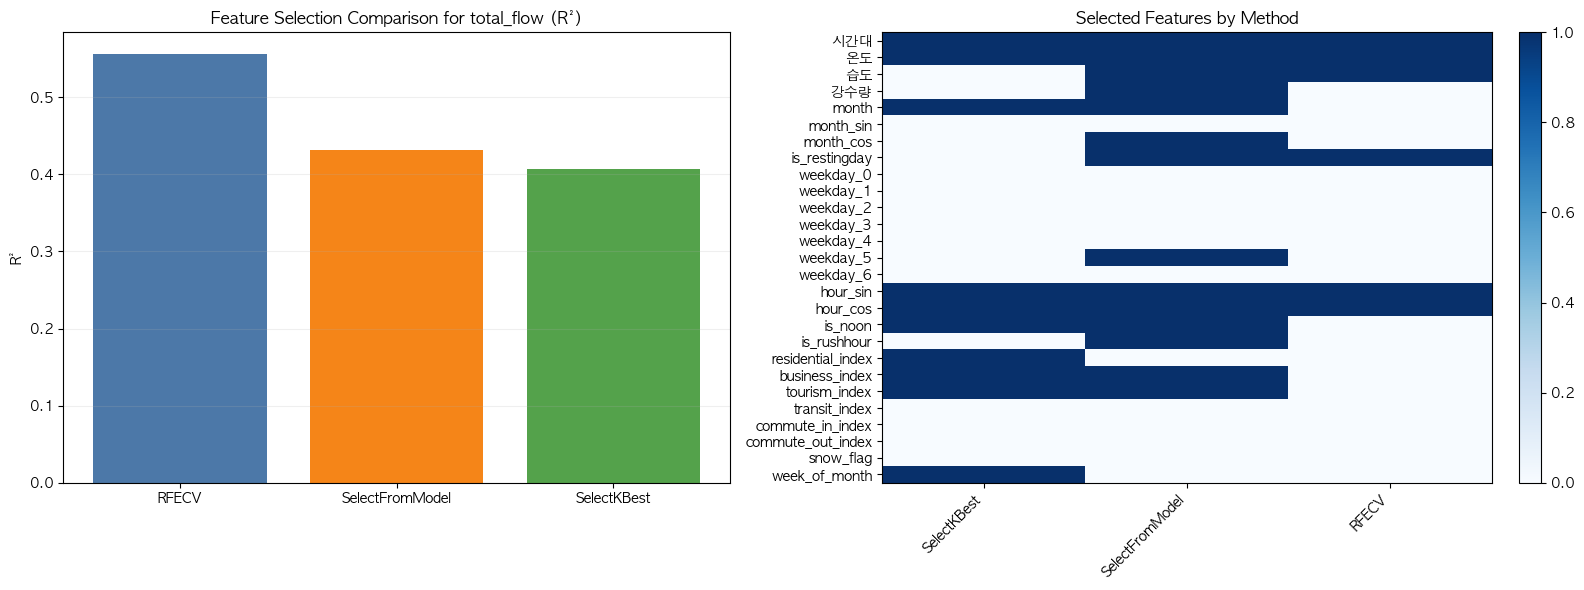

In [666]:
selection_matrix = pd.DataFrame(
    {method: X_train_fs.columns.isin(features).astype(int) for method, features in selected_feature_map.items()},
    index=X_train_fs.columns
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(fs_results['method'], fs_results['r2'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Feature Selection Comparison for total_flow (R²)')
axes[0].set_ylabel('R²')
axes[0].grid(axis='y', alpha=0.2)

im = axes[1].imshow(selection_matrix.values, aspect='auto', cmap='Blues')
axes[1].set_title('Selected Features by Method')
axes[1].set_xticks(range(selection_matrix.shape[1]))
axes[1].set_xticklabels(selection_matrix.columns, rotation=45, ha='right')
axes[1].set_yticks(range(selection_matrix.shape[0]))
axes[1].set_yticklabels(selection_matrix.index)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



In [667]:
best_fs_method = fs_results.iloc[0]['method']
final_selected_features = selected_feature_map[best_fs_method]

print('best_fs_method:', best_fs_method)
print('final_selected_features:')
print(final_selected_features)

best_fs_method: RFECV
final_selected_features:
['시간대', '온도', '습도', 'is_restingday', 'hour_sin', 'hour_cos']


In [668]:
X_train_final = X_train_fs[final_selected_features].copy()
X_test_final = X_test_fs[final_selected_features].copy()

final_fs_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_fs_model.fit(X_train_final, y_train_fs)
final_fs_pred = final_fs_model.predict(X_test_final)

final_fs_metrics = pd.DataFrame([{
    'model': 'RandomForest + selected features',
    'method': best_fs_method,
    'n_features': len(final_selected_features),
    'r2': r2_score(y_test_fs, final_fs_pred),
    'mae': mean_absolute_error(y_test_fs, final_fs_pred),
    'rmse': mean_squared_error(y_test_fs, final_fs_pred) ** 0.5,
}])

display(final_fs_metrics)

,model,method,n_features,r2,mae,rmse
0,RandomForest + selected features,RFECV,6,0.556384,2.920768,4.095786


,feature,importance
0,시간대,0.395461
1,hour_cos,0.181144
2,온도,0.141599
3,hour_sin,0.106705
4,is_restingday,0.093140
5,습도,0.081951


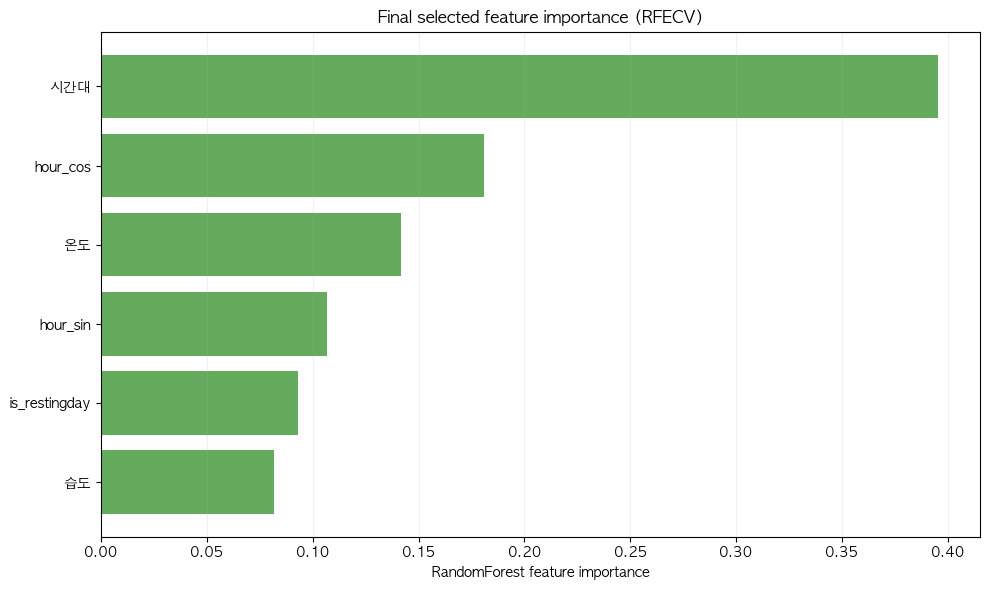

In [669]:
final_feature_importance = pd.DataFrame({
    'feature': final_selected_features,
    'importance': final_fs_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(final_feature_importance)

plt.figure(figsize=(10, 6))
plot_df = final_feature_importance.sort_values('importance', ascending=True)
plt.barh(plot_df['feature'], plot_df['importance'], color='#54A24B', alpha=0.9)
plt.title(f'Final selected feature importance ({best_fs_method})')
plt.xlabel('RandomForest feature importance')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

## External Test: ST-481_2025

이 섹션은 `2024` 데이터를 학습용으로 사용하고, `2025` 데이터를 외부 테스트셋으로 사용해 일반화 성능을 확인하는 단계입니다.

### 데이터 구성
- `train`: `ST-481.csv`의 시간대별 집계 데이터
- `test`: `ST-481_2025.csv`의 시간대별 집계 데이터
- 테스트셋은 `2025-01-09`부터 `2025-12-31`까지이며, 월 기준으로 `1~12월`이 모두 포함됩니다.
- `종료_대여소_ID == 'X'` 인 행은 제거한 뒤 집계합니다.

### 사용 피처
- 현재 시점 피처만 사용합니다.
- 사용 피처: `온도`, `습도`, `강수량`, `snow_flag`, `is_restingday`, `month_sin`, `month_cos`, `hour_sin`, `hour_cos`
- `lag / rolling` 피처는 사용하지 않습니다.

### 예측 타깃
- `inflow`
- `outflow`
- `total_flow`

### 평가 방식
- 먼저 `2024` train 데이터를 시간순으로 `input` 과 `valid` 로 나눕니다.
- 이후 `2024` 전체로 다시 학습한 모델을 `2025` 외부 테스트셋에 적용합니다.
- 확인 지표는 `R²`, `MAE`, `RMSE` 입니다.



In [670]:
train_raw = pd.read_csv('../../../Data/sort_data/preprocessed_6station/ST-481.csv')
test_raw = pd.read_csv('../../../Data/sort_data/preprocessed_6station/ST-481_2025.csv')

for dataset in [train_raw, test_raw]:
    dataset['기준_날짜'] = pd.to_datetime(dataset['기준_날짜'])
    dataset['timestamp'] = dataset['기준_날짜'] + pd.to_timedelta(dataset['시간대'], unit='h')

train_raw = train_raw.loc[~train_raw['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')].copy()
test_raw = test_raw.loc[~test_raw['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')].copy()

external_features = ['온도', '습도', '강수량', 'snow_flag', 'is_restingday', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']

def make_external_hourly(df):
    hourly_df = (
        df.sort_values('timestamp')
          .groupby('timestamp')
          .agg(
              inflow=('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
              outflow=('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
              **{col: (col, 'first') for col in external_features}
          )
    )
    full_idx = pd.date_range(hourly_df.index.min(), hourly_df.index.max(), freq='h')
    hourly_df = hourly_df.reindex(full_idx)
    hourly_df.index.name = 'timestamp'
    hourly_df[['inflow', 'outflow']] = hourly_df[['inflow', 'outflow']].fillna(0)
    for col in external_features:
        hourly_df[col] = hourly_df[col].ffill().bfill()
    hourly_df = hourly_df.reset_index()
    hourly_df['total_flow'] = hourly_df['inflow'] + hourly_df['outflow']
    hourly_df['net_flow'] = hourly_df['inflow'] - hourly_df['outflow']
    return hourly_df

train_external = make_external_hourly(train_raw)
test_external = make_external_hourly(test_raw)

print('train range:', train_external['timestamp'].min(), '->', train_external['timestamp'].max())
print('test range:', test_external['timestamp'].min(), '->', test_external['timestamp'].max())
print('train rows:', len(train_external), 'test rows:', len(test_external))

train range: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
test range: 2025-01-09 00:00:00 -> 2025-12-31 22:00:00
train rows: 8784 test rows: 8567


### External Coverage Check

이 셀은 외부 테스트셋의 시간 커버리지를 확인합니다.

- 원본 파일의 실제 관측 시간 수
- 시작 시각부터 종료 시각까지의 전체 시간 수
- 누락된 시간 수와 커버리지 비율
- 월별 시간 수

주의할 점은 `ST-481_2025.csv` 자체가 `2025-01-01`부터 시작하지 않는다는 점입니다.
따라서 이 테스트셋은 월은 `1~12월`을 모두 포함하지만, 절대 시간 기준으로는 `2025-01-09 00:00`부터 `2025-12-31 22:00`까지를 평가합니다.


In [671]:
def summarize_hourly_coverage(raw_df, hourly_df, label):
    observed_hours = raw_df['timestamp'].drop_duplicates().sort_values()
    full_range = pd.date_range(observed_hours.min(), observed_hours.max(), freq='h')
    coverage_summary = pd.DataFrame([{
        'dataset': label,
        'start': observed_hours.min(),
        'end': observed_hours.max(),
        'observed_hours': len(observed_hours),
        'full_range_hours': len(full_range),
        'missing_hours': len(full_range.difference(observed_hours)),
        'coverage_ratio': len(observed_hours) / len(full_range),
        'reindexed_hours': len(hourly_df),
    }])
    monthly_hours = (
        observed_hours.to_series(index=observed_hours)
        .groupby(observed_hours.to_period('M'))
        .size()
        .rename('observed_hours')
        .reset_index()
        .rename(columns={'timestamp': 'month'})
    )
    return coverage_summary, monthly_hours

train_coverage_summary, train_monthly_coverage = summarize_hourly_coverage(train_raw, train_external, 'train_2024')
test_coverage_summary, test_monthly_coverage = summarize_hourly_coverage(test_raw, test_external, 'test_2025')

coverage_summary_table = pd.concat([train_coverage_summary, test_coverage_summary], ignore_index=True)
coverage_summary_table['coverage_ratio'] = coverage_summary_table['coverage_ratio'].round(4)
coverage_summary_table = coverage_summary_table.replace({
    'dataset': {'train_2024': '학습_2024', 'test_2025': '테스트_2025'}
}).rename(columns={
    'dataset': '데이터셋',
    'start': '시작시각',
    'end': '종료시각',
    'observed_hours': '관측_시간수',
    'full_range_hours': '전체구간_시간수',
    'missing_hours': '누락_시간수',
    'coverage_ratio': '커버리지',
    'reindexed_hours': '보정후_시간수',
})
monthly_coverage_table = (
    pd.concat([
        train_monthly_coverage.assign(dataset='train_2024'),
        test_monthly_coverage.assign(dataset='test_2025')
    ], ignore_index=True)
    .pivot(index='month', columns='dataset', values='observed_hours')
    .reset_index()
    .rename(columns={
        'month': '월',
        'train_2024': '학습_2024',
        'test_2025': '테스트_2025',
    })
)

print('커버리지 요약 표')
display(coverage_summary_table)
print('월별 관측 시간 수 표')
display(monthly_coverage_table)



AttributeError: 'Series' object has no attribute 'to_series'

In [ ]:
external_test_artifacts = {}
external_test_results = []

for target in ['inflow', 'outflow', 'total_flow']:
    x_input, x_valid, y_input, y_valid = train_test_split(
        train_external[external_features],
        train_external[target],
        test_size=0.2,
        shuffle=False
    )

    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(x_input, np.log1p(y_input))

    pred_input = np.expm1(model.predict(x_input))
    pred_valid = np.expm1(model.predict(x_valid))

    final_model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    final_model.fit(train_external[external_features], np.log1p(train_external[target]))
    pred_test = np.expm1(final_model.predict(test_external[external_features]))

    external_test_artifacts[target] = {
        'x_input': x_input,
        'y_input': y_input,
        'pred_input': pred_input,
        'x_valid': x_valid,
        'y_valid': y_valid,
        'pred_valid': pred_valid,
        'y_test': test_external[target],
        'pred_test': pred_test,
    }

    external_test_results.append({
        'target': target,
        'train_rows': len(x_input),
        'valid_rows': len(x_valid),
        'test_rows': len(test_external),
        'input_r2': r2_score(y_input, pred_input),
        'valid_r2': r2_score(y_valid, pred_valid),
        'test_r2': r2_score(test_external[target], pred_test),
        'input_mae': mean_absolute_error(y_input, pred_input),
        'valid_mae': mean_absolute_error(y_valid, pred_valid),
        'test_mae': mean_absolute_error(test_external[target], pred_test),
        'input_rmse': mean_squared_error(y_input, pred_input) ** 0.5,
        'valid_rmse': mean_squared_error(y_valid, pred_valid) ** 0.5,
        'test_rmse': mean_squared_error(test_external[target], pred_test) ** 0.5,
    })

external_test_results = pd.DataFrame(external_test_results)
display(external_test_results)

,target,train_rows,valid_rows,test_rows,input_r2,valid_r2,test_r2,input_mae,valid_mae,test_mae,input_rmse,valid_rmse,test_rmse
0,inflow,7027,1757,8567,0.690906,0.427042,0.480235,1.729816,2.122158,2.299122,2.491990,2.882284,3.226754
1,outflow,7027,1757,8567,0.631603,0.372584,0.342398,1.793748,2.068946,2.106190,2.554592,2.788077,2.842331
2,total_flow,7027,1757,8567,0.743803,0.474010,0.559543,2.738958,3.262517,3.410379,3.840975,4.459873,4.647895


### External Score Tables

아래 표는 `input / valid / test` 점수를 그래프 없이 표 형태로 정리한 것입니다.


In [ ]:
external_test_summary_table = external_test_results.copy()
external_test_summary_table = external_test_summary_table.replace({
    'target': {
        'inflow': '유입량',
        'outflow': '유출량',
        'total_flow': '총이용량',
    }
}).rename(columns={
    'target': '타깃',
    'train_rows': 'input_행수',
    'valid_rows': 'valid_행수',
    'test_rows': 'test_행수',
    'input_r2': 'input_R2',
    'valid_r2': 'valid_R2',
    'test_r2': 'test_R2',
    'input_mae': 'input_MAE',
    'valid_mae': 'valid_MAE',
    'test_mae': 'test_MAE',
    'input_rmse': 'input_RMSE',
    'valid_rmse': 'valid_RMSE',
    'test_rmse': 'test_RMSE',
})
display(external_test_summary_table.round(4))

external_test_rows_table = external_test_summary_table[['타깃', 'input_행수', 'valid_행수', 'test_행수']].copy()
external_test_r2_table = external_test_summary_table[['타깃', 'input_R2', 'valid_R2', 'test_R2']].copy()
external_test_mae_table = external_test_summary_table[['타깃', 'input_MAE', 'valid_MAE', 'test_MAE']].copy()
external_test_rmse_table = external_test_summary_table[['타깃', 'input_RMSE', 'valid_RMSE', 'test_RMSE']].copy()

print('분할별 행 수 표')
display(external_test_rows_table)
print('분할별 R2 표')
display(external_test_r2_table.round(4))
print('분할별 MAE 표')
display(external_test_mae_table.round(4))
print('분할별 RMSE 표')
display(external_test_rmse_table.round(4))



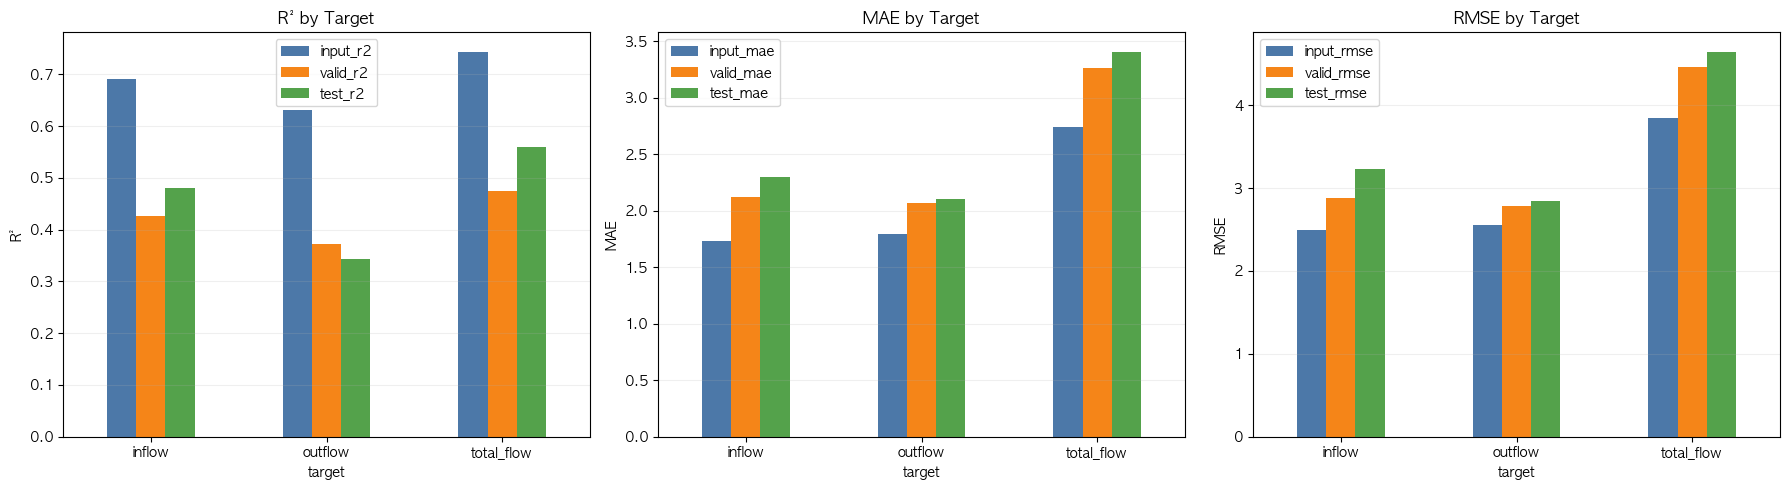

In [ ]:
score_plot_df = external_test_results.set_index('target')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
score_plot_df[['input_r2', 'valid_r2', 'test_r2']].plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('R² by Target')
axes[0].grid(axis='y', alpha=0.2)
axes[0].set_ylabel('R²')

score_plot_df[['input_mae', 'valid_mae', 'test_mae']].plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('MAE by Target')
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_ylabel('MAE')

score_plot_df[['input_rmse', 'valid_rmse', 'test_rmse']].plot(kind='bar', ax=axes[2], color=['#4C78A8', '#F58518', '#54A24B'])
axes[2].set_title('RMSE by Target')
axes[2].grid(axis='y', alpha=0.2)
axes[2].set_ylabel('RMSE')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

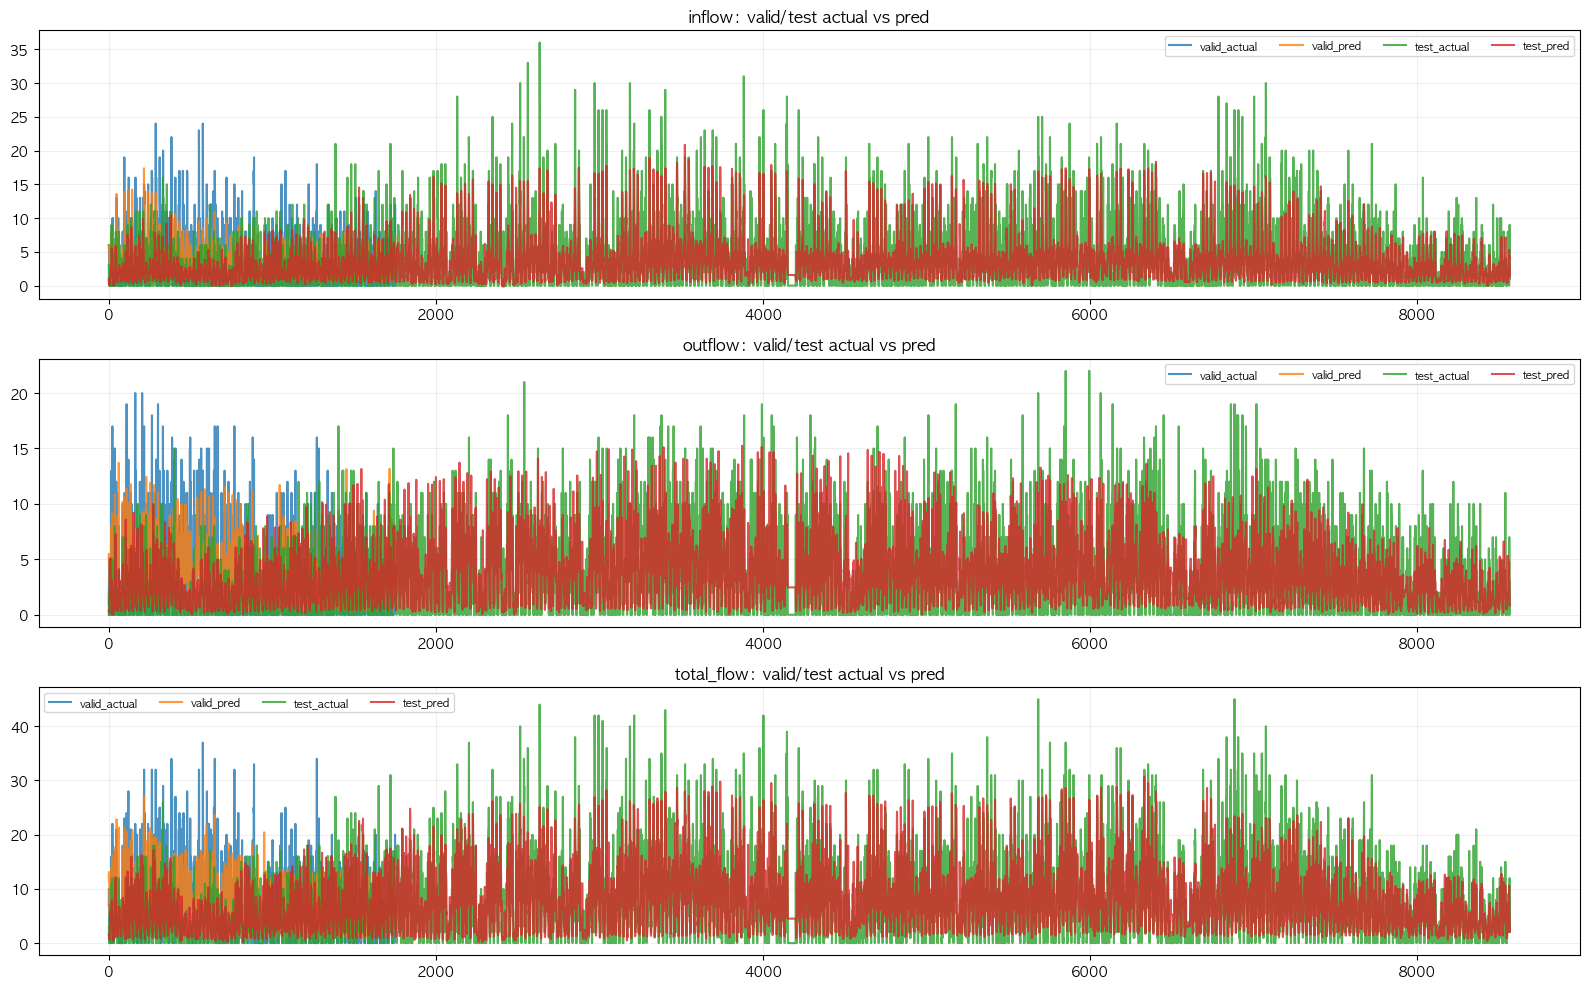

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for ax, target in zip(axes, ['inflow', 'outflow', 'total_flow']):
    art = external_test_artifacts[target]
    ax.plot(art['y_valid'].reset_index(drop=True), label='valid_actual', alpha=0.8)
    ax.plot(pd.Series(art['pred_valid']), label='valid_pred', alpha=0.8)
    ax.plot(pd.Series(art['y_test'].values), label='test_actual', alpha=0.8)
    ax.plot(pd.Series(art['pred_test']), label='test_pred', alpha=0.8)
    ax.set_title(f'{target}: valid/test actual vs pred')
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

## External Test: LinearRegression vs RidgeCV

이 섹션은 같은 데이터 분할과 같은 피처셋에서 `LinearRegression` 과 `RidgeCV` 를 직접 비교하기 위한 단계입니다.

### 비교 목적
- 정규화가 없는 기본 선형회귀와
- L2 규제가 들어간 `RidgeCV`
를 같은 조건에서 비교합니다.

### 데이터 분할
- `input`: `2024` train 데이터의 앞 80%
- `valid`: `2024` train 데이터의 뒤 20%
- `test`: `ST-481_2025.csv` 전체 월

### 왜 `input_r2` 가 갑자기 낮아졌는가?
이전 점수와 지금 점수는 **같은 모델 결과가 아닙니다.**

이전에는:
- `HistGradientBoostingRegressor`
- `log1p(y)` 변환
- 비선형 관계 학습 가능

지금은:
- `LinearRegression` 또는 `RidgeCV`
- 타깃 변환 없음
- 완전한 선형 관계만 가정

즉, 모델의 표현력이 크게 줄어들었기 때문에 `input_r2` 가 낮아진 것이 정상입니다.
`Ridge` 를 넣었다고 해서 성능이 올라가는 모델이 된 것이 아니라, 기존 선형회귀의 계수를 더 안정적으로 만드는 방향에 가깝습니다.

### 추가로 낮아진 이유
- 현재 피처셋은 시간/날씨의 기본 정보만 포함합니다.
- `lag / rolling` 없이 현재 시점 피처만 쓰기 때문에 설명 가능한 정보량이 제한됩니다.
- 단일 스테이션의 시간대 수요는 출퇴근 패턴, 계절성, 비선형 효과가 커서 선형모델만으로 설명력이 충분히 높게 나오기 어렵습니다.

### 해석 포인트
- `input_r2` 와 `valid_r2` 가 둘 다 낮으면 모델 자체 설명력이 약한 상태입니다.
- `input_r2` 는 높은데 `valid_r2` 가 낮으면 과적합 가능성을 봐야 합니다.
- 이번 비교에서는 `LinearRegression` 과 `RidgeCV` 의 차이가 매우 작다면, 규제 유무보다 피처 표현력과 모델 구조가 더 큰 문제라는 뜻입니다.



In [ ]:
linear_compare_models = {
    'LinearRegression': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LinearRegression()
    ),
    'RidgeCV': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-3, 3, 30))
    ),
}

linear_compare_artifacts = {}
linear_compare_results = []

for target in ['inflow', 'outflow', 'total_flow']:
    x_input, x_valid, y_input, y_valid = train_test_split(
        train_external[external_features],
        train_external[target],
        test_size=0.2,
        shuffle=False
    )

    linear_compare_artifacts[target] = {}

    for model_name, model in linear_compare_models.items():
        model.fit(x_input, y_input)
        pred_input = model.predict(x_input)
        pred_valid = model.predict(x_valid)

        final_model = linear_compare_models[model_name]
        final_model.fit(train_external[external_features], train_external[target])
        pred_test = final_model.predict(test_external[external_features])

        linear_compare_artifacts[target][model_name] = {
            'y_valid': y_valid.reset_index(drop=True),
            'pred_valid': pd.Series(pred_valid),
            'y_test': test_external[target].reset_index(drop=True),
            'pred_test': pd.Series(pred_test),
        }

        linear_compare_results.append({
            'model': model_name,
            'target': target,
            'input_r2': r2_score(y_input, pred_input),
            'valid_r2': r2_score(y_valid, pred_valid),
            'test_r2': r2_score(test_external[target], pred_test),
            'input_mae': mean_absolute_error(y_input, pred_input),
            'valid_mae': mean_absolute_error(y_valid, pred_valid),
            'test_mae': mean_absolute_error(test_external[target], pred_test),
            'input_rmse': mean_squared_error(y_input, pred_input) ** 0.5,
            'valid_rmse': mean_squared_error(y_valid, pred_valid) ** 0.5,
            'test_rmse': mean_squared_error(test_external[target], pred_test) ** 0.5,
        })

linear_compare_results = pd.DataFrame(linear_compare_results)
display(linear_compare_results.round(4))


,model,target,input_r2,valid_r2,test_r2,input_mae,valid_mae,test_mae,input_rmse,valid_rmse,test_rmse
0,LinearRegression,inflow,0.2879,0.2591,0.2660,2.8283,2.5075,2.8019,3.7825,3.2776,3.8344
1,RidgeCV,inflow,0.2879,0.2608,0.2666,2.8271,2.5031,2.7992,3.7825,3.2739,3.8330
2,LinearRegression,outflow,0.1684,0.1764,0.2122,2.9363,2.4406,2.4412,3.8381,3.1943,3.1111
3,RidgeCV,outflow,0.1684,0.1780,0.2120,2.9376,2.4395,2.4438,3.8382,3.1914,3.1114
4,LinearRegression,total_flow,0.2782,0.2738,0.3134,4.9341,3.9945,4.4025,6.4470,5.2404,5.8028
5,RidgeCV,total_flow,0.2782,0.2766,0.3138,4.9350,3.9848,4.4011,6.4472,5.2303,5.8013


### LinearRegression vs RidgeCV Tables

모델 비교 결과를 표 중심으로 확인하는 셀입니다.


In [ ]:
linear_compare_table = linear_compare_results.copy()
linear_compare_table = linear_compare_table.replace({
    'model': {
        'LinearRegression': '선형회귀',
        'RidgeCV': '릿지CV',
    },
    'target': {
        'inflow': '유입량',
        'outflow': '유출량',
        'total_flow': '총이용량',
    }
}).rename(columns={
    'model': '모델',
    'target': '타깃',
    'input_r2': 'input_R2',
    'valid_r2': 'valid_R2',
    'test_r2': 'test_R2',
    'input_mae': 'input_MAE',
    'valid_mae': 'valid_MAE',
    'test_mae': 'test_MAE',
    'input_rmse': 'input_RMSE',
    'valid_rmse': 'valid_RMSE',
    'test_rmse': 'test_RMSE',
})
display(linear_compare_table.round(4))

linear_compare_pivot_r2 = linear_compare_table.pivot(index='타깃', columns='모델', values='test_R2').reset_index()
linear_compare_pivot_mae = linear_compare_table.pivot(index='타깃', columns='모델', values='test_MAE').reset_index()
linear_compare_pivot_rmse = linear_compare_table.pivot(index='타깃', columns='모델', values='test_RMSE').reset_index()

print('테스트 R2 비교 표')
display(linear_compare_pivot_r2.round(4))
print('테스트 MAE 비교 표')
display(linear_compare_pivot_mae.round(4))
print('테스트 RMSE 비교 표')
display(linear_compare_pivot_rmse.round(4))



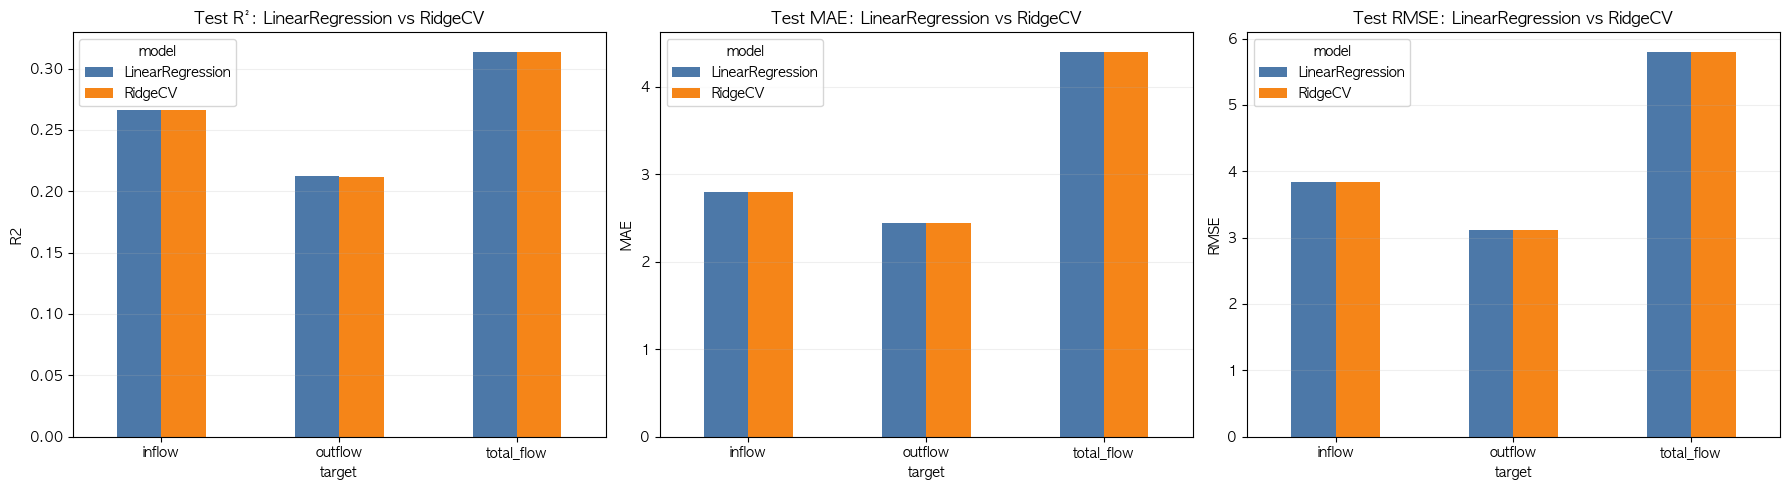

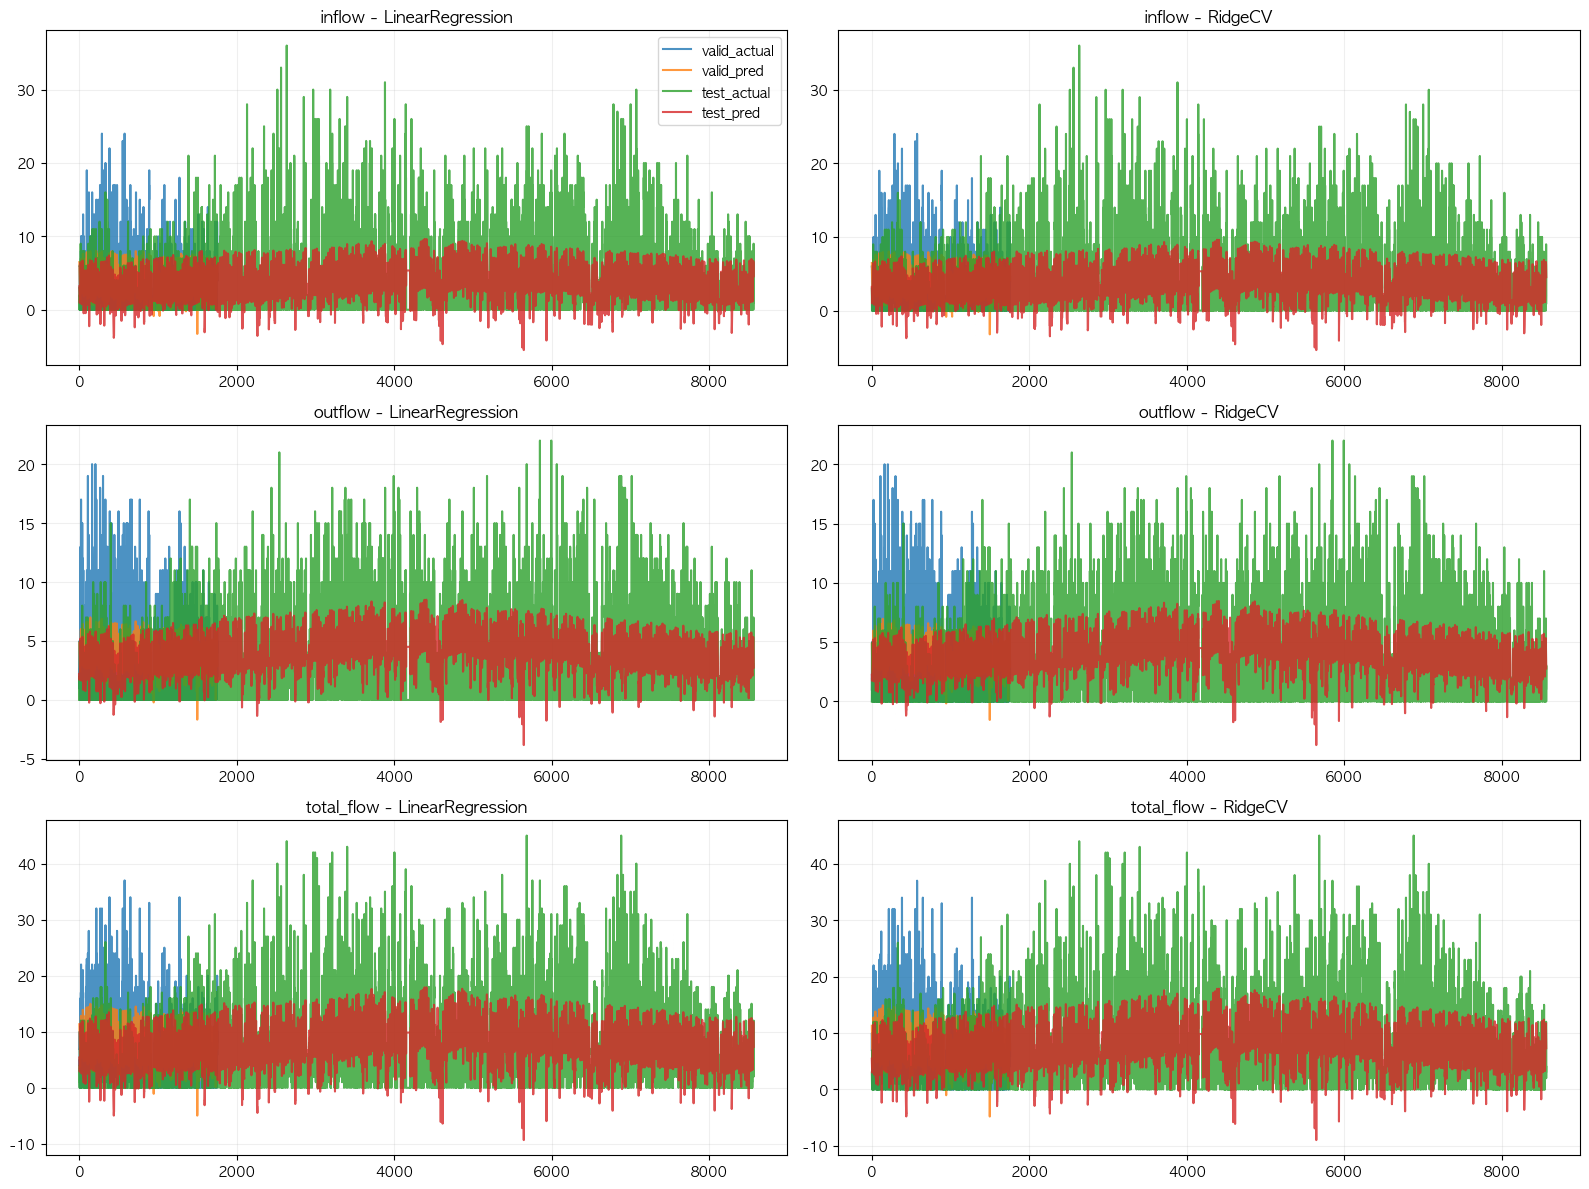

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    ['test_r2', 'test_mae', 'test_rmse'],
    ['Test R²: LinearRegression vs RidgeCV', 'Test MAE: LinearRegression vs RidgeCV', 'Test RMSE: LinearRegression vs RidgeCV']
):
    pivot_df = linear_compare_results.pivot(index='target', columns='model', values=metric)
    pivot_df.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518'])
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.2)
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(metric.replace('test_', '').upper())

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=False)

for row_idx, target in enumerate(['inflow', 'outflow', 'total_flow']):
    for col_idx, model_name in enumerate(['LinearRegression', 'RidgeCV']):
        ax = axes[row_idx, col_idx]
        art = linear_compare_artifacts[target][model_name]
        ax.plot(art['y_valid'], label='valid_actual', alpha=0.8)
        ax.plot(art['pred_valid'], label='valid_pred', alpha=0.8)
        ax.plot(art['y_test'], label='test_actual', alpha=0.8)
        ax.plot(art['pred_test'], label='test_pred', alpha=0.8)
        ax.set_title(f'{target} - {model_name}')
        ax.grid(alpha=0.2)
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
